# Fase 1 — Full Experiment: Timing Grid × Priority Mechanism

Deze notebook combineert:
- **Calibrate_Timing parameter grid** (alle timing-configuraties: baseline, periodic, event-driven, hybrid)
- **Fase1 priority grid** (3 priority-mechanismen: no_priority, static, dynamic)

**Cartesiaans product:** `len(timing_configs) × 3 priorities × N_seeds`

Resume-logica werkt **per seed** (niet per config-map):
- Eerste run: stel `TARGET_SEEDS = 50` → alle configs vullen tot 50 seeds
- Tweede run: stel `TARGET_SEEDS = 100` → seeds 50..99 worden toegevoegd aan bestaande raw_runs.csv

Met flags kun je kiezen welke trigger-types meegenomen worden (baseline/periodic kunnen veel runs schelen).


## 1. Setup — paden, imports & batch-instellingen

In [1]:
import sys, io, warnings, time, json
from pathlib import Path
from contextlib import redirect_stdout
from itertools import product, combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

from run_simulation import run_simulation
from utils.metrics import (
    compute_metrics, build_result_row, save_result_row,
    aggregate_config, load_all_aggregated,
)

# ── Paden ──────────────────────────────────────────────────────────────────
RESULTS_DIR = Path.cwd().parent / "results" / "fase1_full_extreme_weights_5"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Results dir: {RESULTS_DIR.resolve()}")


Results dir: /Users/ddw/Desktop/Rescheduling/results/fase1_full_extreme_weights_5


### 1.1 Batch-instellingen — **PAS DIT AAN VOOR ELKE RUN**

`TARGET_SEEDS` bepaalt tot welke seed elke config moet gevuld zijn.

- **Eerste run** (eerste 50 seeds): zet `TARGET_SEEDS = 50`
- **Tweede run** (verder tot seed 100): zet `TARGET_SEEDS = 100`
- enz.

Configs die al voldoende seeds hebben worden volledig overgeslagen.
Voor configs met minder seeds dan `TARGET_SEEDS` worden alleen de ontbrekende seeds gerund.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║                    BATCH-INSTELLINGEN (AANPASSEN!)                  ║
# ╚══════════════════════════════════════════════════════════════════════╝
TARGET_SEEDS = 50          # Vul elke config tot dit aantal seeds (0..TARGET_SEEDS-1)

# ── Welke trigger-types meenemen? ──────────────────────────────────────────
INCLUDE_BASELINE     = True   # FCFS only — 1 config (periodic_freq=100_000)
INCLUDE_PERIODIC     = True   # 7 configs (verschillende periodic_freq)
INCLUDE_EVENT_DRIVEN = True    # 39 configs (5 ed_rf × cf × 3 tc)
INCLUDE_HYBRID       = True    # 66 configs (22 (ed_rf,cf,prf) × 3 tc)

# ── Welke priorities meenemen? ─────────────────────────────────────────────
INCLUDE_NO_PRIORITY = True
INCLUDE_STATIC      = True
INCLUDE_DYNAMIC     = True

# ── Per-seed sim-output (df met trein-niveau detail) als parquet bewaren? ──
# True  = parquets per seed komen in cfg_dir/<auto_naam>/seed_X.parquet
#         (handig voor latere diepteanalyses zonder reruns)
# False = alleen raw_runs.csv met geaggregeerde metrics (lichter op disk)
SAVE_PER_SEED_PARQUET = True

# ── Vaste simulatieparameters (overgenomen van Calibrate_Timing) ───────────
N_FREIGHT          = 182      # ≈15% freight share
FREIGHT_PCT        = 0.15
GAMMA              = 120      # s — dynamic_threshold (uit calibrate_gamma)
MC_DELAY_PER_TRAIN = 180      # s — Monte-Carlo delay per actieve trein
SOLVER_TIMEOUT     = 60       # s
PHASE              = 1

# ── Priority-gewichten (overgenomen van Fase1) ─────────────────────────────
WEIGHT_PASS_PRIO = 5    # weight_passenger als priority actief (static/dynamic)
WEIGHT_FREIGHT_PRIO = 1  # weight_freight als priority actief
UPGRADE_WEIGHT      = 5     # extra penalty als delay >= gamma (alleen bij dynamic)

print(f"TARGET_SEEDS     = {TARGET_SEEDS}")
print(f"Triggers actief  : baseline={INCLUDE_BASELINE}, periodic={INCLUDE_PERIODIC}, "
      f"event_driven={INCLUDE_EVENT_DRIVEN}, hybrid={INCLUDE_HYBRID}")
print(f"Priorities actief: no_priority={INCLUDE_NO_PRIORITY}, "
      f"static={INCLUDE_STATIC}, dynamic={INCLUDE_DYNAMIC}")
print(f"Save parquets    = {SAVE_PER_SEED_PARQUET}")
print(f"GAMMA            = {GAMMA}s  |  MC_DELAY = {MC_DELAY_PER_TRAIN}s")


TARGET_SEEDS     = 5
Triggers actief  : baseline=True, periodic=True, event_driven=True, hybrid=True
Priorities actief: no_priority=True, static=True, dynamic=True
Save parquets    = True
GAMMA            = 120s  |  MC_DELAY = 180s


## 2. Configuratie-grid bouwen

Timing-grid is letterlijk overgenomen uit `Calibrate_Timing.ipynb`. Priority-grid uit `Fase1_Experiment.ipynb`.

Het Cartesiaans product geeft de totale lijst van te runnen configuraties.

In [3]:
# ── Timing-configuraties (uit Calibrate_Timing.ipynb) ──────────────────────
timing_configs = []

# Baseline: FCFS only (periodic, RF=100_000 → solver triggert nooit)
if INCLUDE_BASELINE:
    timing_configs.append({
        "trigger_strategy":     "periodic",
        "periodic_freq":        100_000,
        "event_driven_freq":    900,
        "controller_freq":      300,
        "threshold_confidence": 0.6,
    })

# Periodic — 7 verschillende periodic_freq waarden
if INCLUDE_PERIODIC:
    for prf in [300, 600, 900, 1800, 3600, 5400, 7200]:
        timing_configs.append({
            "trigger_strategy":     "periodic",
            "periodic_freq":        prf,
            "event_driven_freq":    900,
            "controller_freq":      300,
            "threshold_confidence": 0.6,
        })

# Event-Driven — 13 (ed_rf, cf) paren × 3 threshold_confidence
if INCLUDE_EVENT_DRIVEN:
    ed_rf_cf_map = {
        600:  [300, 600],
        900:  [450, 900],
        1800: [450, 900, 1800],
        3600: [900, 1800, 3600],
        5400: [1800, 3600, 5400],
    }
    tc_values = [0.4, 0.6, 0.8]
    for ed_rf, cf_list in ed_rf_cf_map.items():
        for cf in cf_list:
            for tc in tc_values:
                timing_configs.append({
                    "trigger_strategy":     "event_driven",
                    "event_driven_freq":    ed_rf,
                    "controller_freq":      cf,
                    "threshold_confidence": tc,
                    "periodic_freq":        100_000,
                })

# Hybrid — 22 (ed_rf, cf, prf) combos × 3 tc
if INCLUDE_HYBRID:
    hybrid_combos = [
        # bestaand
        (1800, 900,  3600), (1800, 1800, 3600),
        (1800, 900,  5400), (1800, 1800, 5400),
        (1800, 900,  7200), (1800, 1800, 7200),
        (3600, 900,  5400), (3600, 1800, 5400), (3600, 3600, 5400),
        (3600, 900,  7200), (3600, 1800, 7200), (3600, 3600, 7200),
        (5400, 900,  7200), (5400, 1800, 7200),
        # nieuw: ed_rf=900
        (900, 450, 1800), (900, 450, 3600),
        (900, 900, 1800), (900, 900, 3600),
        # nieuw: ed_rf=600
        (600, 300, 1800), (600, 300, 3600),
        (600, 600, 1800), (600, 600, 3600),
    ]
    tc_values = [0.4, 0.6, 0.8]
    for ed_rf, cf, prf in hybrid_combos:
        for tc in tc_values:
            timing_configs.append({
                "trigger_strategy":     "hybrid",
                "event_driven_freq":    ed_rf,
                "controller_freq":      cf,
                "periodic_freq":        prf,
                "threshold_confidence": tc,
            })

print(f"Totaal timing-configs: {len(timing_configs)}")
print(f"  baseline:     {sum(1 for c in timing_configs if c['trigger_strategy']=='periodic' and c['periodic_freq']==100_000)}")
print(f"  periodic:     {sum(1 for c in timing_configs if c['trigger_strategy']=='periodic' and c['periodic_freq']!=100_000)}")
print(f"  event_driven: {sum(1 for c in timing_configs if c['trigger_strategy']=='event_driven')}")
print(f"  hybrid:       {sum(1 for c in timing_configs if c['trigger_strategy']=='hybrid')}")


Totaal timing-configs: 113
  baseline:     1
  periodic:     7
  event_driven: 39
  hybrid:       66


In [4]:
# ── Priority-configuraties (uit Fase1_Experiment.ipynb) ───────────────────
priority_configs = {}

if INCLUDE_NO_PRIORITY:
    priority_configs["no_priority"] = dict(
        objective_strategy = "static",
        weight_passenger   = 1,
        weight_freight     = 1,
        upgrade_weight     = UPGRADE_WEIGHT,
        dynamic_threshold  = GAMMA,
    )
if INCLUDE_STATIC:
    priority_configs["static"] = dict(
        objective_strategy = "static",
        weight_passenger   = WEIGHT_PASS_PRIO,
        weight_freight     = WEIGHT_FREIGHT_PRIO,
        upgrade_weight     = UPGRADE_WEIGHT,
        dynamic_threshold  = GAMMA,
    )
if INCLUDE_DYNAMIC:
    priority_configs["dynamic"] = dict(
        objective_strategy = "dynamic",
        weight_passenger   = WEIGHT_PASS_PRIO,
        weight_freight     = WEIGHT_FREIGHT_PRIO,
        upgrade_weight     = UPGRADE_WEIGHT,
        dynamic_threshold  = GAMMA,
    )

PRIORITY_ORDER = [p for p in ["no_priority", "static", "dynamic"] if p in priority_configs]
TRIGGER_ORDER  = [t for t in ["periodic", "event_driven", "hybrid"]
                  if any(c["trigger_strategy"] == t for c in timing_configs)]

print(f"Priorities: {PRIORITY_ORDER}")
print(f"Triggers:   {TRIGGER_ORDER}")

# ── Volledig grid: Cartesiaans product ────────────────────────────────────
CONFIGS = list(product(timing_configs, PRIORITY_ORDER))

print(f"\nTotaal configs (timing × priority): {len(CONFIGS)}")
print(f"Totaal runs voor TARGET_SEEDS={TARGET_SEEDS}: {len(CONFIGS) * TARGET_SEEDS}")


Priorities: ['no_priority', 'static', 'dynamic']
Triggers:   ['periodic', 'event_driven', 'hybrid']

Totaal configs (timing × priority): 339
Totaal runs voor TARGET_SEEDS=5: 1695


## 3. Helper-functies

### 3.1 Config-naam → directory

Naming-schema is menselijk leesbaar en uniek per parameter-combinatie:

- **Baseline**: `baseline_{priority}`
- **Periodic**: `periodic_prf{prf}_{priority}`
- **Event-driven**: `event_driven_edf{ed_rf}_cf{cf}_tc{tc}_{priority}`
- **Hybrid**: `hybrid_edf{ed_rf}_cf{cf}_prf{prf}_tc{tc}_{priority}`

In [5]:
def config_name(timing: dict, priority: str) -> str:
    """Construeer een unieke, leesbare directorynaam per (timing × priority) combinatie."""
    ts = timing["trigger_strategy"]
    if ts == "periodic" and timing["periodic_freq"] == 100_000:
        return f"baseline_{priority}"
    elif ts == "periodic":
        return f"periodic_prf{timing['periodic_freq']}_{priority}"
    elif ts == "event_driven":
        return (f"event_driven_edf{timing['event_driven_freq']}"
                f"_cf{timing['controller_freq']}"
                f"_tc{timing['threshold_confidence']:.2f}"
                f"_{priority}")
    elif ts == "hybrid":
        return (f"hybrid_edf{timing['event_driven_freq']}"
                f"_cf{timing['controller_freq']}"
                f"_prf{timing['periodic_freq']}"
                f"_tc{timing['threshold_confidence']:.2f}"
                f"_{priority}")
    else:
        raise ValueError(f"Onbekende trigger_strategy: {ts}")


# Sanity check: alle namen uniek?
all_names = [config_name(t, p) for t, p in CONFIGS]
assert len(all_names) == len(set(all_names)), "Configuratie-namen niet uniek!"
print(f"✓ {len(all_names)} unieke config-namen.")
print(f"\nVoorbeelden:")
for nm in all_names[:5]:
    print(f"  {nm}")
print(f"  ... ({len(all_names)-5} meer)")


✓ 339 unieke config-namen.

Voorbeelden:
  baseline_no_priority
  baseline_static
  baseline_dynamic
  periodic_prf300_no_priority
  periodic_prf300_static
  ... (334 meer)


### 3.2 Resume-logica per seed

In [6]:
def completed_seeds(cfg_dir: Path) -> set:
    """Set van seeds die al in raw_runs.csv staan voor deze config."""
    csv_path = cfg_dir / "raw_runs.csv"
    if not csv_path.exists():
        return set()
    try:
        df = pd.read_csv(csv_path, usecols=["seed"])
        return set(df["seed"].astype(int).tolist())
    except Exception:
        return set()


def seeds_to_run(cfg_dir: Path, target: int) -> list:
    """Lijst van nog-niet-uitgevoerde seeds in range(0, target)."""
    done = completed_seeds(cfg_dir)
    needed = set(range(target)) - done
    return sorted(needed)


### 3.3 Eén run uitvoeren

Combineert de aanpak van Calibrate (deadlock-detection, `mc_delay_per_train`) en Fase1 (`save_result_row` per seed, output naar eigen dir).

**Belangrijk:** we passeren `output_dir=cfg_dir` zodat de auto-aangemaakte config-map van `run_simulation` netjes **binnen** onze eigen config-map terechtkomt (en niet als losse map in `results/`). Met `save=SAVE_PER_SEED_PARQUET` controleer je of de per-seed parquets bewaard worden.

In [7]:
def run_one(timing: dict, priority: str, seed: int, cfg_dir: Path) -> dict:
    """
    Voert één simulatierun uit en bouwt een result-row.
    Bij deadlock wordt een speciale row terug gegeven (met deadlock=True).
    Simulatie-output (SKIPPED/TRIGGERED) wordt onderdrukt.

    Parameters
    ----------
    cfg_dir : Path
        Onze eigen config-directory waarin raw_runs.csv én (optioneel) de
        auto-submap met seed_X.parquet files terechtkomen.
    """
    pcfg = priority_configs[priority]

    sim_kwargs = dict(
        n_freight            = N_FREIGHT,
        seed                 = seed,
        save                 = SAVE_PER_SEED_PARQUET,
        output_dir           = cfg_dir,          # leidt auto-map binnen cfg_dir
        mc_delay_per_train   = MC_DELAY_PER_TRAIN,
        # timing
        trigger_strategy     = timing["trigger_strategy"],
        event_driven_freq    = timing["event_driven_freq"],
        controller_freq      = timing["controller_freq"],
        periodic_freq        = timing["periodic_freq"],
        threshold_confidence = timing["threshold_confidence"],
        # priority
        objective_strategy   = pcfg["objective_strategy"],
        weight_passenger     = pcfg["weight_passenger"],
        weight_freight       = pcfg["weight_freight"],
        upgrade_weight       = pcfg["upgrade_weight"],
        dynamic_threshold    = pcfg["dynamic_threshold"],
    )

    buf = io.StringIO()
    with redirect_stdout(buf):
        state, df_sim, meta, _ = run_simulation(**sim_kwargs)

    # Deadlock detection (uit Calibrate_Timing) ────────────────────────────
    if meta.get("deadlock_detected", False):
        deadlock_row = build_result_row(
            seed             = seed,
            phase            = PHASE,
            metrics          = {"TED_combined": None, "TED_passenger": None,
                                "TED_freight": None, "delay_ratio": None},
            meta             = meta,
            strategy_type    = timing["trigger_strategy"],
            periodic_rf      = timing["periodic_freq"],
            event_driven_rf  = timing["event_driven_freq"],
            controller_freq  = timing["controller_freq"],
            threshold_conf   = timing["threshold_confidence"],
            priority         = priority,
            weight_passenger = pcfg["weight_passenger"],
            weight_freight   = pcfg["weight_freight"],
            gamma            = pcfg["dynamic_threshold"] if priority == "dynamic" else None,
            upgrade          = pcfg["upgrade_weight"] if priority == "dynamic" else None,
            objective        = "final_delay",
            freight_pct      = FREIGHT_PCT,
            mc_delay_per_train = MC_DELAY_PER_TRAIN,
            solver_timeout   = SOLVER_TIMEOUT,
        )
        deadlock_row["deadlock"] = True
        return deadlock_row

    # Normale run ────────────────────────────────────────────────────────────
    metrics = compute_metrics(df_sim)
    n_pass  = metrics.get("n_passenger", 0)
    total   = n_pass + N_FREIGHT if n_pass > 0 else N_FREIGHT
    frt_pct = N_FREIGHT / total if total > 0 else FREIGHT_PCT

    row = build_result_row(
        seed             = seed,
        phase            = PHASE,
        metrics          = metrics,
        meta             = meta,
        strategy_type    = timing["trigger_strategy"],
        periodic_rf      = timing["periodic_freq"],
        event_driven_rf  = timing["event_driven_freq"],
        controller_freq  = timing["controller_freq"],
        threshold_conf   = timing["threshold_confidence"],
        priority         = priority,
        weight_passenger = pcfg["weight_passenger"],
        weight_freight   = pcfg["weight_freight"],
        gamma            = pcfg["dynamic_threshold"] if priority == "dynamic" else None,
        upgrade          = pcfg["upgrade_weight"] if priority == "dynamic" else None,
        objective        = "final_delay",
        freight_pct      = round(frt_pct, 4),
        mc_delay_per_train = MC_DELAY_PER_TRAIN,
        solver_timeout   = SOLVER_TIMEOUT,
    )
    row["deadlock"] = False
    return row


def load_seed_parquet(cfg_dir: Path, seed: int) -> pd.DataFrame:
    """
    Laadt de simulatie-output (df met trein-niveau detail) voor een specifieke
    seed binnen een config. Werkt alleen als SAVE_PER_SEED_PARQUET=True actief was
    tijdens de runs.

    Voorbeeld:
        cfg = RESULTS_DIR / "event_driven_edf900_cf450_tc0.40_dynamic"
        df  = load_seed_parquet(cfg, seed=7)
    """
    candidates = list(cfg_dir.rglob(f"seed_{seed}.parquet"))
    if not candidates:
        raise FileNotFoundError(
            f"Geen parquet voor seed {seed} in {cfg_dir}. "
            f"Was SAVE_PER_SEED_PARQUET=True actief?"
        )
    if len(candidates) > 1:
        print(f"Waarschuwing: meerdere matches voor seed {seed}, neem eerste: {candidates[0]}")
    return pd.read_parquet(candidates[0])


## 4. Hoofdlus — runs uitvoeren

**Resume-safe op seed-niveau**: voor elke config worden alleen ontbrekende seeds binnen `range(0, TARGET_SEEDS)` gerund.

Onderbreken met `KeyboardInterrupt` is veilig: voltooide seeds blijven bewaard in `raw_runs.csv`.

**Map-structuur per config:**
```
results/fase1_full/
└── <config_name>/                              ← onze map (incl. priority in naam)
    ├── raw_runs.csv                            ← geaggregeerde metrics per seed
    └── n182_..._mc120/                         ← auto-map van run_simulation
        ├── seed_0.parquet                      ← trein-niveau detail (als SAVE_PER_SEED_PARQUET=True)
        ├── seed_1.parquet
        └── ...
```
Als `SAVE_PER_SEED_PARQUET=False` wordt de auto-map automatisch opgeruimd na elke seed.

Voor latere analyse van een individuele seed: gebruik `load_seed_parquet(cfg_dir, seed)`.

In [8]:
# ── Voortgangs-tracking ────────────────────────────────────────────────────
total_runs_target = sum(
    len(seeds_to_run(RESULTS_DIR / config_name(t, p), TARGET_SEEDS))
    for t, p in CONFIGS
)

print(f"Te runnen seeds in deze batch: {total_runs_target}")
print(f"Totaal configs:                {len(CONFIGS)}")
print()

if total_runs_target == 0:
    print("✓ Alles al gerund — geen nieuwe seeds nodig met huidige TARGET_SEEDS.")
    print(f"  Verhoog TARGET_SEEDS om meer seeds te runnen.")

completed_batch = 0
errors          = []
t_batch_start   = time.time()

try:
    for cfg_idx, (timing, priority) in enumerate(CONFIGS):
        cname   = config_name(timing, priority)
        cfg_dir = RESULTS_DIR / cname
        cfg_dir.mkdir(parents=True, exist_ok=True)

        todo = seeds_to_run(cfg_dir, TARGET_SEEDS)
        done = TARGET_SEEDS - len(todo)

        if not todo:
            # Config al volledig — kort statusbericht
            if cfg_idx % 20 == 0:  # niet elke iteratie spammen
                print(f"[{cfg_idx+1:03d}/{len(CONFIGS):03d}] ✓ {cname}  ({done}/{TARGET_SEEDS} seeds, klaar)")
            continue

        print(f"\n[{cfg_idx+1:03d}/{len(CONFIGS):03d}] {cname}")
        print(f"          reeds gedaan: {done}/{TARGET_SEEDS}  →  nu te runnen: {len(todo)} seeds")

        t_cfg_start = time.time()
        for seed in todo:
            t0 = time.time()
            try:
                row = run_one(timing, priority, seed, cfg_dir)
                save_result_row(row, cfg_dir)
                completed_batch += 1

                # Cleanup: als we GEEN parquets bewaren, ruim de lege auto-subdir op
                # die run_simulation altijd aanmaakt onder output_dir.
                if not SAVE_PER_SEED_PARQUET:
                    for child in cfg_dir.iterdir():
                        if child.is_dir() and not any(child.iterdir()):
                            try:
                                child.rmdir()
                            except OSError:
                                pass  # niet leeg, laat staan

                # Compacte voortgangslog elke 10 seeds (of bij eerste/laatste)
                if (seed % 10 == 0) or (seed == todo[-1]):
                    ted     = row.get("TED_combined")
                    dr      = row.get("delay_ratio")
                    elapsed = time.time() - t0
                    pct     = completed_batch / total_runs_target * 100
                    dl_mark = " [DEADLOCK]" if row.get("deadlock") else ""
                    ted_s   = f"{ted:>6.0f}s" if ted is not None else "      ?"
                    dr_s    = f"{dr:.2f}"     if dr  is not None else "  ?"
                    print(f"          seed {seed:3d} | TED={ted_s} | DR={dr_s:>5} "
                          f"| {elapsed:.1f}s  [{pct:5.1f}%]{dl_mark}")

            except KeyboardInterrupt:
                raise
            except Exception as e:
                errors.append((cname, seed, str(e)))
                print(f"          seed {seed:3d} | ERROR: {e}")

        print(f"          └─ {cname} klaar in {(time.time()-t_cfg_start)/60:.1f} min")

except KeyboardInterrupt:
    print(f"\n⚠  Onderbroken na {completed_batch}/{total_runs_target} runs in deze batch.")
    print("   Voltooide seeds blijven bewaard; herstart pikt deze automatisch op.")

t_batch_min = (time.time() - t_batch_start) / 60
print(f"\n{'='*70}")
print(f"Batch klaar: {completed_batch}/{total_runs_target} runs in {t_batch_min:.1f} min")
if errors:
    print(f"\n⚠  Errors ({len(errors)}):")
    for cname, seed, msg in errors[:20]:
        print(f"  {cname} seed {seed}: {msg}")
    if len(errors) > 20:
        print(f"  ... en nog {len(errors)-20} meer")
else:
    print("Geen errors.")


Te runnen seeds in deze batch: 0
Totaal configs:                339

✓ Alles al gerund — geen nieuwe seeds nodig met huidige TARGET_SEEDS.
  Verhoog TARGET_SEEDS om meer seeds te runnen.
[001/339] ✓ baseline_no_priority  (5/5 seeds, klaar)
[021/339] ✓ periodic_prf5400_dynamic  (5/5 seeds, klaar)
[041/339] ✓ event_driven_edf600_cf600_tc0.80_static  (5/5 seeds, klaar)
[061/339] ✓ event_driven_edf1800_cf450_tc0.40_no_priority  (5/5 seeds, klaar)
[081/339] ✓ event_driven_edf1800_cf1800_tc0.40_dynamic  (5/5 seeds, klaar)
[101/339] ✓ event_driven_edf3600_cf1800_tc0.60_static  (5/5 seeds, klaar)
[121/339] ✓ event_driven_edf5400_cf1800_tc0.80_no_priority  (5/5 seeds, klaar)
[141/339] ✓ event_driven_edf5400_cf5400_tc0.80_dynamic  (5/5 seeds, klaar)
[161/339] ✓ hybrid_edf1800_cf900_prf5400_tc0.40_static  (5/5 seeds, klaar)
[181/339] ✓ hybrid_edf1800_cf900_prf7200_tc0.60_no_priority  (5/5 seeds, klaar)
[201/339] ✓ hybrid_edf3600_cf900_prf5400_tc0.60_dynamic  (5/5 seeds, klaar)
[221/339] ✓ hybrid_

---
## 5. Resultaten laden & valideren

In [9]:
def load_all_raw() -> pd.DataFrame:
    """Laadt alle raw_runs.csv bestanden uit RESULTS_DIR in één DataFrame."""
    frames = []
    for cfg_dir in sorted(RESULTS_DIR.iterdir()):
        if not cfg_dir.is_dir():
            continue
        csv_path = cfg_dir / "raw_runs.csv"
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            df["config"] = cfg_dir.name
            frames.append(df)
    if not frames:
        print("Geen resultaten gevonden.")
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


raw = load_all_raw()
print(f"Geladen: {len(raw)} rijen uit {raw['config'].nunique()} configs")

# Filter deadlocks uit voor performantie-analyses (maar bewaar voor overzicht)
if "deadlock" in raw.columns:
    n_deadlock = raw["deadlock"].fillna(False).astype(bool).sum()
    print(f"Deadlocks: {n_deadlock} runs (worden uitgesloten van metric-analyses)")
    raw_all = raw.copy()
    raw = raw[~raw["deadlock"].fillna(False).astype(bool)].copy()
else:
    raw_all = raw.copy()

# Canonieke ordering
raw["trigger"]  = pd.Categorical(raw["strategy_type"], categories=TRIGGER_ORDER, ordered=True)
raw["priority"] = pd.Categorical(raw["priority"],      categories=PRIORITY_ORDER, ordered=True)

print(f"\nNa filtering deadlocks: {len(raw)} rijen voor analyse")


Geladen: 6817 rijen uit 339 configs
Deadlocks: 87 runs (worden uitgesloten van metric-analyses)

Na filtering deadlocks: 6730 rijen voor analyse


In [10]:
# ── Voltooiing per trigger × priority (geaggregeerd over alle timing-params) ─
completion = (
    raw_all.groupby(["strategy_type", "priority"])["seed"]
    .count()
    .unstack("priority")
    .reindex(index=TRIGGER_ORDER, columns=PRIORITY_ORDER)
    .fillna(0).astype(int)
)
print("Aantal runs per (trigger × priority):")
display(completion)

# ── Per individuele config: ben je volledig op TARGET_SEEDS? ───────────────
per_config = raw_all.groupby("config").agg(
    n_seeds   = ("seed",     "count"),
    n_deadlock= ("deadlock", lambda x: x.fillna(False).astype(bool).sum()) if "deadlock" in raw_all.columns else ("seed", lambda x: 0),
)
per_config["complete"] = per_config["n_seeds"] >= TARGET_SEEDS

n_full     = per_config["complete"].sum()
n_partial  = (~per_config["complete"]).sum()
print(f"\nConfigs met ≥ {TARGET_SEEDS} seeds: {n_full}/{len(per_config)}")
print(f"Configs met minder:              {n_partial}")
if n_partial > 0 and n_partial <= 20:
    print(f"\nIncomplete configs:")
    display(per_config[~per_config["complete"]].sort_values("n_seeds"))


Aantal runs per (trigger × priority):


priority,no_priority,static,dynamic
strategy_type,,,
periodic,400,77,40
event_driven,1950,195,195
hybrid,3300,330,330



Configs met ≥ 5 seeds: 339/339
Configs met minder:              0


---
## 6. Analyse

De analyse heeft twee niveaus:

1. **Trigger-type niveau** (3 × 3 grid): aggregeer over alle parametersettings binnen een trigger-type — vergelijkbaar met de oorspronkelijke Fase1-analyse
2. **Parameter niveau**: kijk per timing-parameter (edf, cf, prf, tc) wat het effect is — vergelijkbaar met Calibrate_Timing

### 6.1 Plot-instellingen

In [11]:
TRIGGER_COLORS = {
    "periodic":     "#4C72B0",
    "event_driven": "#DD8452",
    "hybrid":       "#55A868",
}
PRIORITY_COLORS = {
    "no_priority": "#95C8D8",
    "static":      "#E07B54",
    "dynamic":     "#6DBF67",
}
TRIGGER_LABELS  = {"periodic": "Periodic", "event_driven": "Event-Driven", "hybrid": "Hybrid"}
PRIORITY_LABELS = {"no_priority": "No Priority", "static": "Static", "dynamic": "Dynamic"}

# Folder voor figuren
FIG_DIR = RESULTS_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)
print(f"Figuren worden opgeslagen in: {FIG_DIR}")


Figuren worden opgeslagen in: /Users/ddw/Desktop/Rescheduling/results/fase1_full_extreme_weights_5/figures


### 6.2 Overzichtstabel — geaggregeerd per (trigger × priority)

Aggregatie over **alle timing-parameter-combinaties** binnen elk trigger-type. Geeft een eerste indruk.

In [12]:
METRICS = {
    "TED_combined":     "TED Combined (s)",
    "TED_passenger":    "TED Passenger (s)",
    "TED_freight":      "TED Freight (s)",
    "delay_ratio":      "Delay Ratio",
    "total_solve_time": "Solve Time (s)",
    "n_rescheduled":    "N Rescheduled",
}

rows = []
for trigger in TRIGGER_ORDER:
    for priority in PRIORITY_ORDER:
        sub = raw[(raw["trigger"] == trigger) & (raw["priority"] == priority)]
        if sub.empty:
            continue
        r = {"trigger": trigger, "priority": priority, "n_runs": len(sub),
             "n_configs": sub["config"].nunique()}
        for col, label in METRICS.items():
            if col in sub.columns:
                vals = sub[col].dropna()
                r[label] = f"{vals.mean():.1f} ± {vals.std():.1f}" if not vals.empty else "—"
        rows.append(r)

overview = pd.DataFrame(rows).set_index(["trigger", "priority"])
print(f"Geaggregeerd over alle parameterinstellingen per trigger-type:")
display(overview)


Geaggregeerd over alle parameterinstellingen per trigger-type:


n_runs  n_configs  TED Combined (s)  \
trigger      priority                                           
periodic     no_priority     395          8  76636.2 ± 7481.1   
             static           76          8  79435.3 ± 6411.7   
             dynamic          40          8  75992.8 ± 7568.0   
event_driven no_priority    1925         39  79759.4 ± 4306.5   
             static          194         39  79927.4 ± 3791.9   
             dynamic         195         39  79776.2 ± 3943.7   
hybrid       no_priority    3256         66  79187.9 ± 4234.8   
             static          324         66  78946.7 ± 3978.8   
             dynamic         325         66  79238.9 ± 4068.5   

                         TED Passenger (s)   TED Freight (s) Delay Ratio  \
trigger      priority                                                      
periodic     no_priority  64369.7 ± 7237.5  12266.5 ± 1660.4   1.1 ± 0.2   
             static       67193.8 ± 6727.6  12241.5 ± 1747.9   1.0 ± 0.2   
             dynamic      63768.4 ± 7694.7  12224.4 ± 1446.3   1.1 ± 0.2   
event_driven no_priority  67503.9 ± 3748.6  12255.5 ± 1780.0   1.0 ± 0.2   
             static       67778.3 ± 3670.6  12149.1 ± 1359.7   1.0 ± 0.1   
             dynamic      67669.0 ± 3797.9  12107.2 ± 1365.2   1.0 ± 0.1   
hybrid       no_priority  66866.0 ± 3736.4  12321.9 ± 1813.6   1.0 ± 0.2   
             static       66433.3 ± 3570.2  12513.4 ± 1734.6   1.1 ± 0.2   
             dynamic      66662.5 ± 3529.0  12576.4 ± 1799.1   1.1 ± 0.2   

                         Solve Time (s) N Rescheduled  
trigger      priority                                  
periodic     no_priority      0.5 ± 0.6   76.2 ± 87.2  
             static           0.3 ± 0.5   38.6 ± 73.8  
             dynamic          0.5 ± 0.6   75.7 ± 87.7  
event_driven no_priority      0.3 ± 0.2   28.6 ± 21.1  
             static           0.3 ± 0.2   28.9 ± 21.9  
             dynamic          0.3 ± 0.2   29.1 ± 21.8  
hybrid       no_priority      0.3 ± 0.2   39.0 ± 23.3  
             static           0.3 ± 0.2   39.6 ± 23.5  
             dynamic          0.3 ± 0.2   39.2 ± 23.2

### 6.3 Beste config per (trigger × priority) — **kerncombinatie van beide notebooks**

Voor elk van de 9 (trigger × priority) cellen: welke exacte parameter-setting wint op `TED_combined_mean`?

Dit beantwoordt: *"als ik trigger=hybrid en priority=dynamic kies, welke parameter-tuning is dan optimaal?"*

In [13]:
# ── Per (timing config × priority) aggregeren ─────────────────────────────
agg_cols = ["strategy_type", "periodic_rf", "event_driven_rf",
            "controller_freq", "threshold_conf", "priority"]

per_combo = raw.groupby(agg_cols, dropna=False).agg(
    n_seeds            = ("seed",            "count"),
    TED_combined_mean  = ("TED_combined",    "mean"),
    TED_combined_std   = ("TED_combined",    "std"),
    TED_passenger_mean = ("TED_passenger",   "mean"),
    TED_freight_mean   = ("TED_freight",     "mean"),
    delay_ratio_mean   = ("delay_ratio",     "mean"),
    delay_ratio_std    = ("delay_ratio",     "std"),
    solve_time_mean    = ("total_solve_time","mean"),
    n_rescheduled_mean = ("n_rescheduled",   "mean"),
).round(2).reset_index()

# Voor elke (trigger × priority) → laagste TED_combined_mean kiezen
best_per_cell = (
    per_combo
    .sort_values("TED_combined_mean")
    .groupby(["strategy_type", "priority"], dropna=False)
    .first()
    .reset_index()
    .sort_values(["strategy_type", "priority"])
)

print("Beste timing-config per (trigger × priority) — kerntabel:")
display(best_per_cell[[
    "strategy_type", "priority", "periodic_rf", "event_driven_rf",
    "controller_freq", "threshold_conf",
    "TED_combined_mean", "delay_ratio_mean", "solve_time_mean", "n_seeds"
]])

# Opslaan
best_per_cell.to_csv(RESULTS_DIR / "best_config_per_cell.csv", index=False)
print(f"\nOpgeslagen: {RESULTS_DIR / 'best_config_per_cell.csv'}")


Beste timing-config per (trigger × priority) — kerntabel:


,strategy_type,priority,periodic_rf,event_driven_rf,controller_freq,threshold_conf,TED_combined_mean,delay_ratio_mean,solve_time_mean,n_seeds
0,event_driven,no_priority,100000,600,300,0.4,73649.97,1.15,0.75,50
1,event_driven,static,100000,600,300,0.4,74066.86,1.22,0.77,5
2,event_driven,dynamic,100000,600,300,0.6,73494.70,1.19,0.70,5
3,hybrid,no_priority,1800,600,300,0.4,73473.50,1.19,0.74,50
4,hybrid,static,3600,600,300,0.4,72572.88,1.18,0.84,5
5,hybrid,dynamic,1800,600,300,0.6,73949.68,1.19,0.74,5
6,periodic,no_priority,300,900,300,0.6,61847.36,1.41,1.85,50
7,periodic,static,300,900,300,0.6,62648.42,1.65,1.82,5
8,periodic,dynamic,300,900,300,0.6,60732.18,1.47,1.78,5



Opgeslagen: /Users/ddw/Desktop/Rescheduling/results/fase1_full_extreme_weights_5/best_config_per_cell.csv


### 6.4 Heatmaps — 3×3 grid (trigger × priority)

Gemiddelden zijn geaggregeerd over alle timing-parametersettings binnen elk trigger-type.

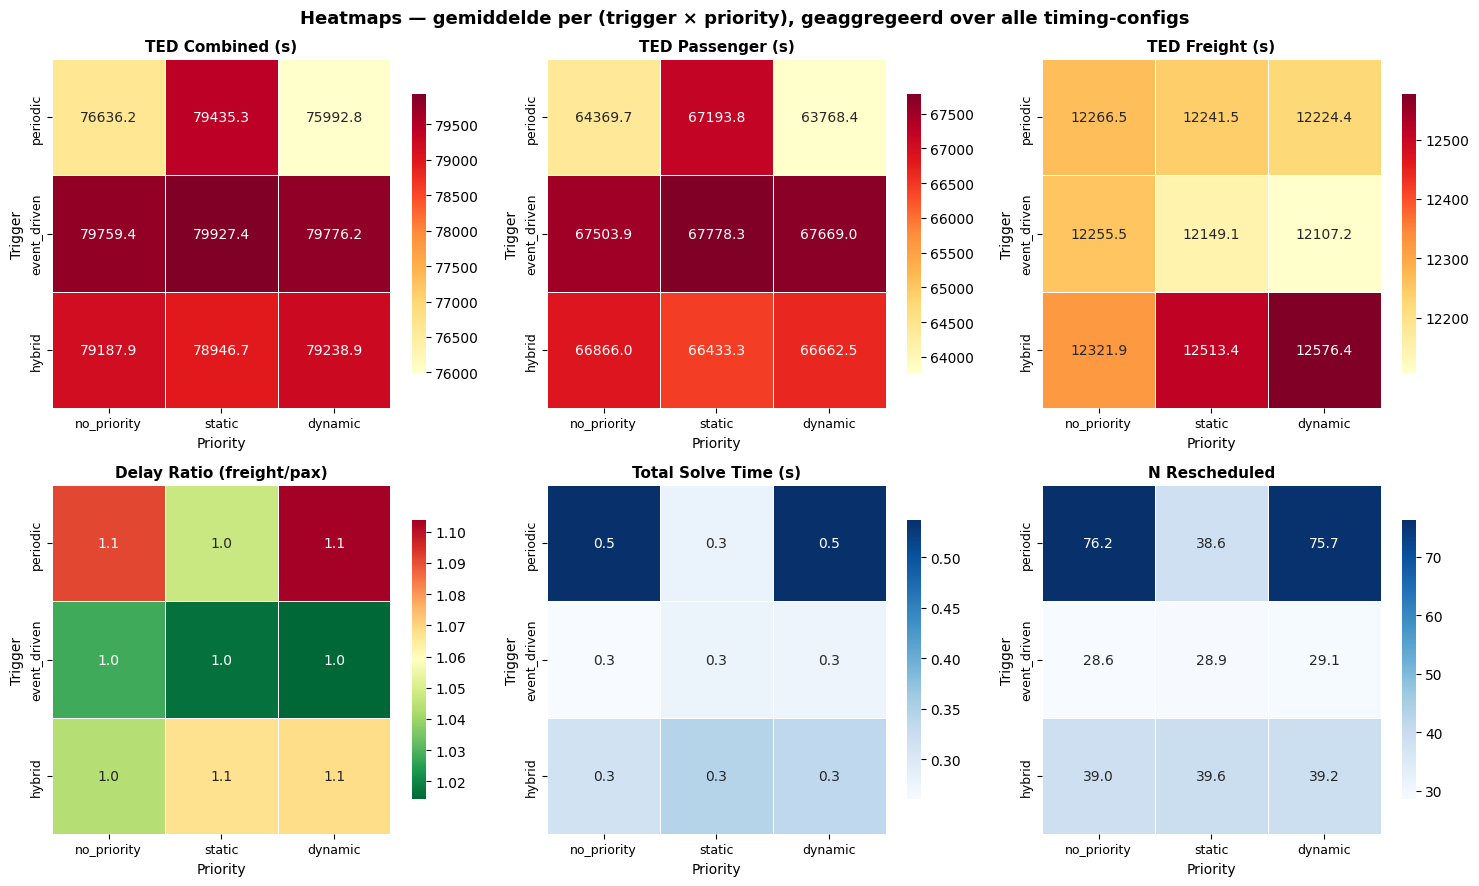

In [14]:
def make_pivot(metric: str) -> pd.DataFrame:
    return (
        raw.groupby(["trigger", "priority"], observed=True)[metric]
        .mean()
        .unstack("priority")
        .reindex(index=TRIGGER_ORDER, columns=PRIORITY_ORDER)
    )

HEATMAP_METRICS = [
    ("TED_combined",     "TED Combined (s)",           "YlOrRd"),
    ("TED_passenger",    "TED Passenger (s)",          "YlOrRd"),
    ("TED_freight",      "TED Freight (s)",            "YlOrRd"),
    ("delay_ratio",      "Delay Ratio (freight/pax)",  "RdYlGn_r"),
    ("total_solve_time", "Total Solve Time (s)",       "Blues"),
    ("n_rescheduled",    "N Rescheduled",              "Blues"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Heatmaps — gemiddelde per (trigger × priority), geaggregeerd over alle timing-configs",
             fontsize=13, fontweight="bold")

for ax, (metric, label, cmap) in zip(axes.flat, HEATMAP_METRICS):
    if metric not in raw.columns:
        ax.set_title(f"{label}\n(kolom ontbreekt)"); ax.axis("off"); continue
    pivot = make_pivot(metric)
    if pivot.isnull().all().all():
        ax.set_title(f"{label}\n(geen data)"); ax.axis("off"); continue
    sns.heatmap(pivot, ax=ax, cmap=cmap, annot=True, fmt=".1f",
                linewidths=0.5, linecolor="white",
                cbar_kws={"shrink": 0.8})
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Priority"); ax.set_ylabel("Trigger")
    ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "heatmaps_aggregated.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.5 Boxplots — verdeling per (trigger × priority)

Elke box bevat alle runs binnen die trigger-type × priority combinatie (over alle timing-parametersettings én alle seeds).

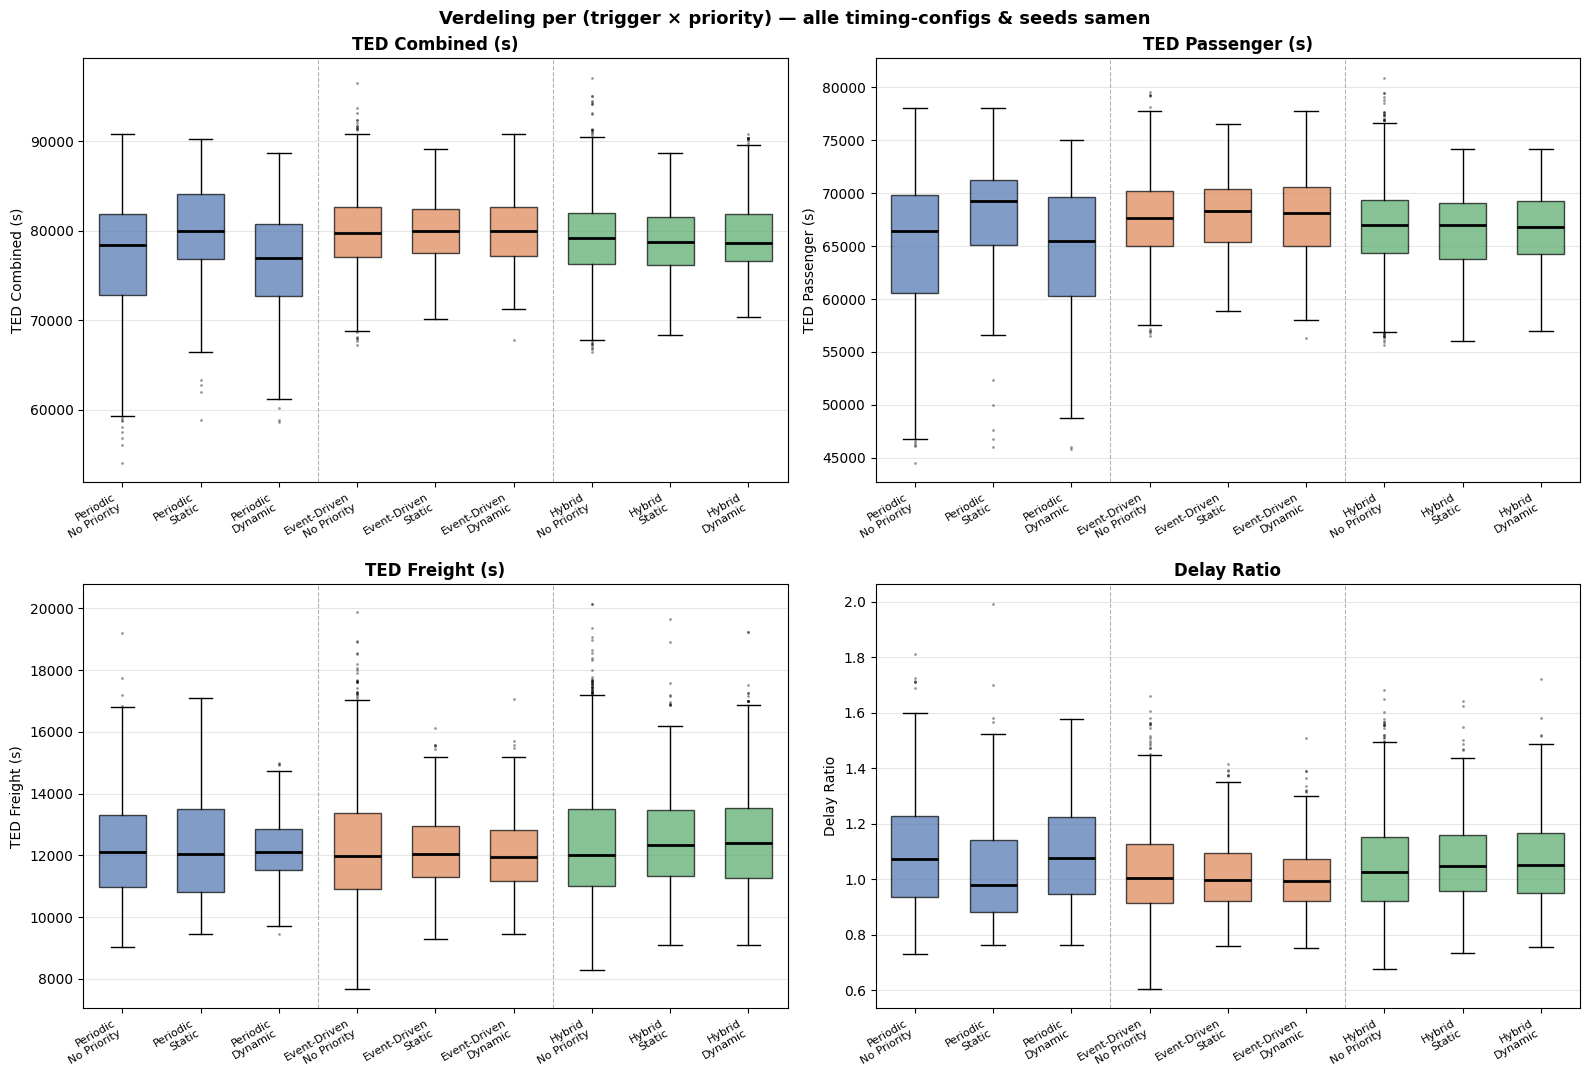

In [15]:
BOX_METRICS = [
    ("TED_combined",  "TED Combined (s)"),
    ("TED_passenger", "TED Passenger (s)"),
    ("TED_freight",   "TED Freight (s)"),
    ("delay_ratio",   "Delay Ratio"),
]

grid_cells = [(t, p) for t in TRIGGER_ORDER for p in PRIORITY_ORDER]
x_labels = [f"{TRIGGER_LABELS[t]}\n{PRIORITY_LABELS[p]}" for t, p in grid_cells]
x_pos = np.arange(len(grid_cells))

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Verdeling per (trigger × priority) — alle timing-configs & seeds samen",
             fontsize=13, fontweight="bold")

for ax, (metric, ylabel) in zip(axes.flat, BOX_METRICS):
    if metric not in raw.columns:
        ax.set_title(f"{ylabel}\n(geen data)"); ax.axis("off"); continue

    data = [
        raw[(raw["trigger"] == t) & (raw["priority"] == p)][metric].dropna().values
        for t, p in grid_cells
    ]
    bp = ax.boxplot(data, positions=x_pos, widths=0.6, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2),
                    flierprops=dict(marker=".", markersize=2, alpha=0.4))
    for patch, (t, _) in zip(bp["boxes"], grid_cells):
        patch.set_facecolor(TRIGGER_COLORS[t]); patch.set_alpha(0.7)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=8, rotation=30, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

    # Verticale scheidingslijnen per trigger-groep
    for sep_i in range(len(TRIGGER_ORDER)-1):
        sep_pos = (sep_i+1) * len(PRIORITY_ORDER) - 0.5
        ax.axvline(sep_pos, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig(FIG_DIR / "boxplots_aggregated.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.6 Effect van individuele timing-parameters

Hier kijken we hoe elke afzonderlijke parameter (event_driven_freq, controller_freq, periodic_freq, threshold_confidence) de uitkomst beïnvloedt, gefacetteerd op priority.

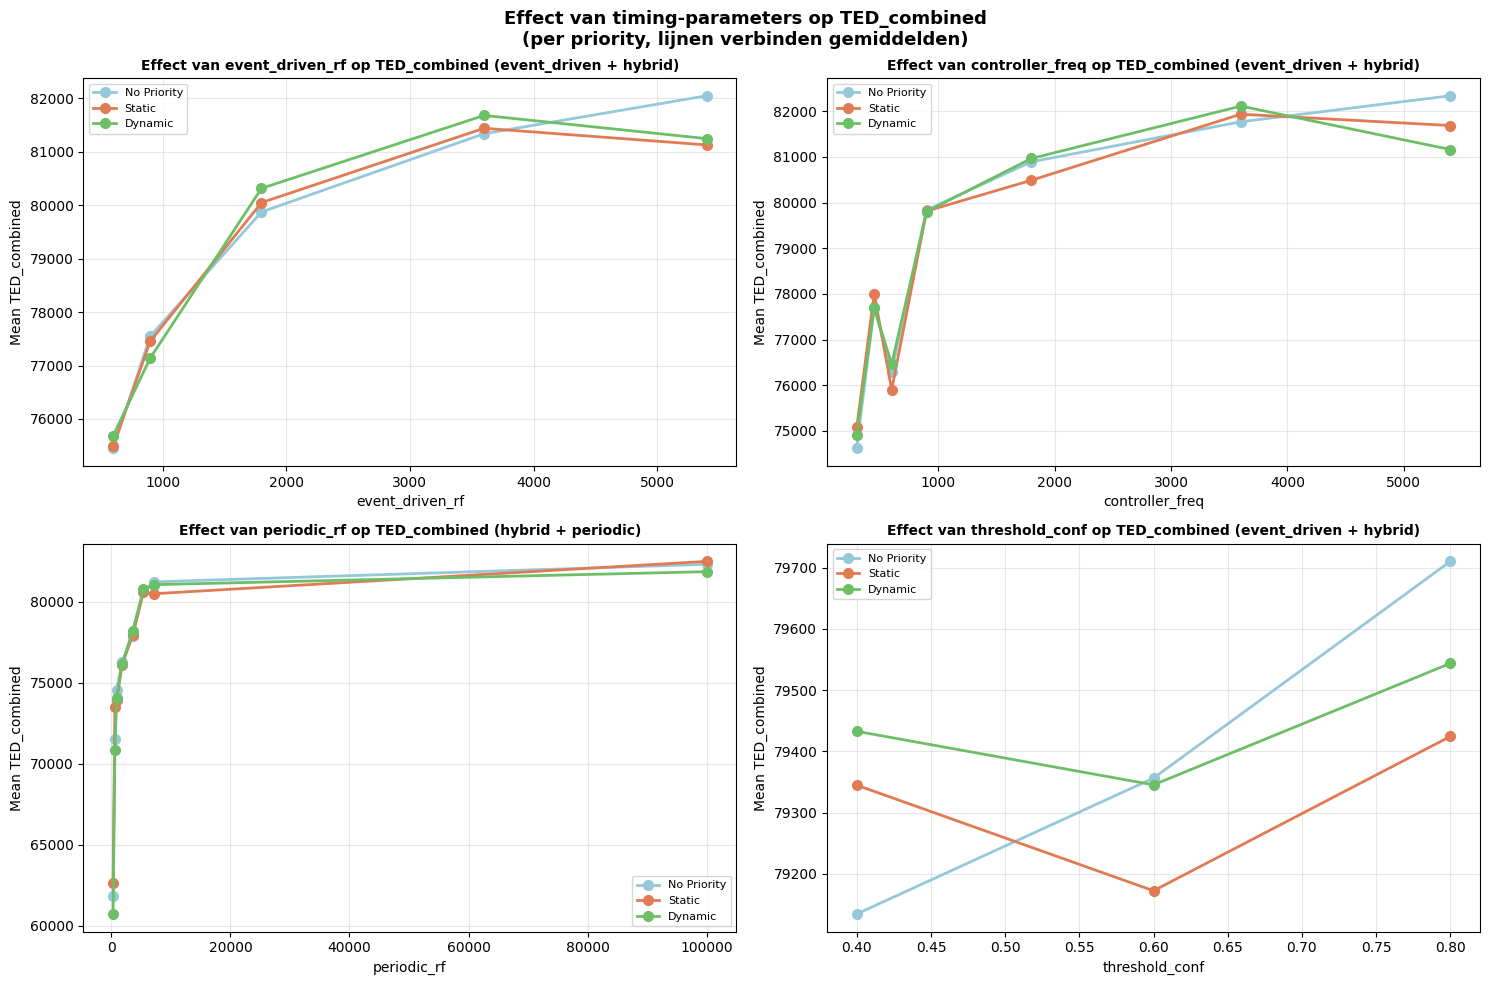

In [16]:
def plot_param_effect(param: str, metric: str = "TED_combined",
                      restrict_strategy: list = None,
                      ax=None, title_suffix: str = ""):
    """Boxplot van metric als functie van param, gefacetteerd over priority."""
    sub = raw.copy()
    if restrict_strategy:
        sub = sub[sub["strategy_type"].isin(restrict_strategy)]
    sub = sub[sub[param].notna()]
    if sub.empty:
        return

    values_sorted = sorted(sub[param].unique())
    for priority in PRIORITY_ORDER:
        data = [
            sub[(sub[param] == v) & (sub["priority"] == priority)][metric].dropna().values
            for v in values_sorted
        ]
        means = [np.mean(d) if len(d) > 0 else np.nan for d in data]
        ax.plot(values_sorted, means, marker="o", linewidth=2, markersize=7,
                label=PRIORITY_LABELS[priority],
                color=PRIORITY_COLORS[priority])

    ax.set_xlabel(param)
    ax.set_ylabel(f"Mean {metric}")
    ax.set_title(f"Effect van {param} op {metric}{title_suffix}", fontsize=10, fontweight="bold")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

# ── 4-paneel: edf, cf, prf, tc ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Effect van timing-parameters op TED_combined\n(per priority, lijnen verbinden gemiddelden)",
             fontsize=13, fontweight="bold")

plot_param_effect("event_driven_rf",  "TED_combined",
                  restrict_strategy=["event_driven", "hybrid"],
                  ax=axes[0,0], title_suffix=" (event_driven + hybrid)")
plot_param_effect("controller_freq",  "TED_combined",
                  restrict_strategy=["event_driven", "hybrid"],
                  ax=axes[0,1], title_suffix=" (event_driven + hybrid)")
plot_param_effect("periodic_rf",      "TED_combined",
                  restrict_strategy=["hybrid", "periodic"],
                  ax=axes[1,0], title_suffix=" (hybrid + periodic)")
plot_param_effect("threshold_conf",   "TED_combined",
                  restrict_strategy=["event_driven", "hybrid"],
                  ax=axes[1,1], title_suffix=" (event_driven + hybrid)")

plt.tight_layout()
plt.savefig(FIG_DIR / "param_effects_TED.png", dpi=150, bbox_inches="tight")
plt.show()


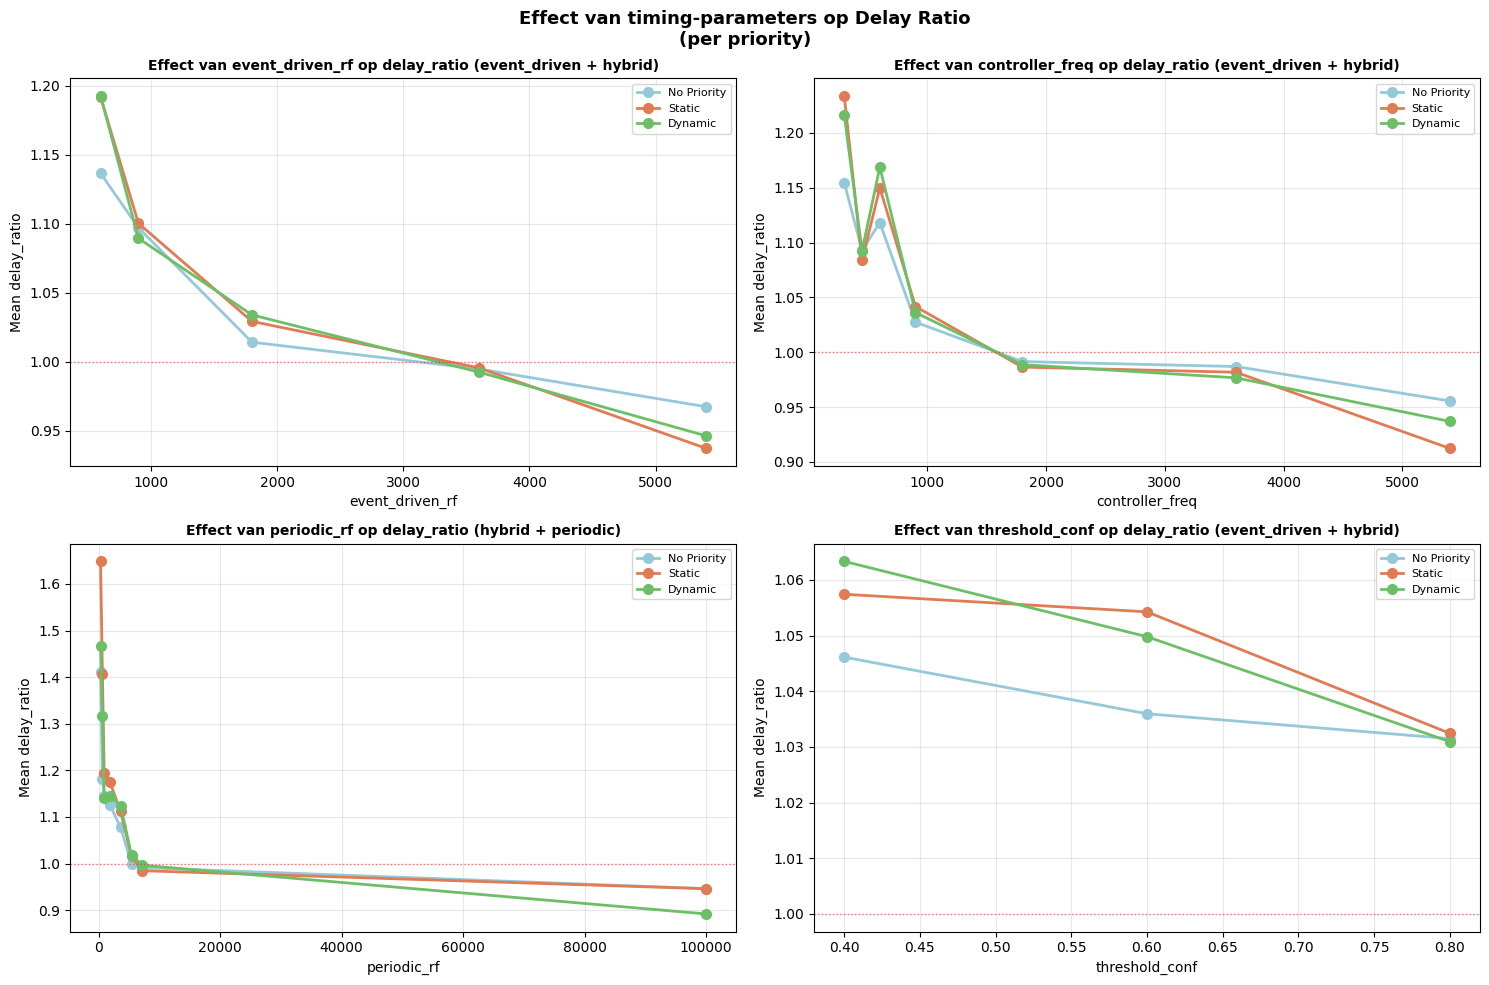

In [17]:
# Hetzelfde maar dan voor delay_ratio
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Effect van timing-parameters op Delay Ratio\n(per priority)",
             fontsize=13, fontweight="bold")

plot_param_effect("event_driven_rf",  "delay_ratio",
                  restrict_strategy=["event_driven", "hybrid"],
                  ax=axes[0,0], title_suffix=" (event_driven + hybrid)")
plot_param_effect("controller_freq",  "delay_ratio",
                  restrict_strategy=["event_driven", "hybrid"],
                  ax=axes[0,1], title_suffix=" (event_driven + hybrid)")
plot_param_effect("periodic_rf",      "delay_ratio",
                  restrict_strategy=["hybrid", "periodic"],
                  ax=axes[1,0], title_suffix=" (hybrid + periodic)")
plot_param_effect("threshold_conf",   "delay_ratio",
                  restrict_strategy=["event_driven", "hybrid"],
                  ax=axes[1,1], title_suffix=" (event_driven + hybrid)")

for ax in axes.flat:
    ax.axhline(1.0, color="red", linestyle=":", linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig(FIG_DIR / "param_effects_DR.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.7 Pareto-analyse — performantie vs. solver-effort, per priority

Voor elke priority: scatter elke (timing-config, mean over seeds) op (solve_time, TED_combined). Identificeer de Pareto-front (minimaliseer beide).

Dit is de uitbreiding van Calibrate_Timing maar nu gefacetteerd per priority-mechanisme.

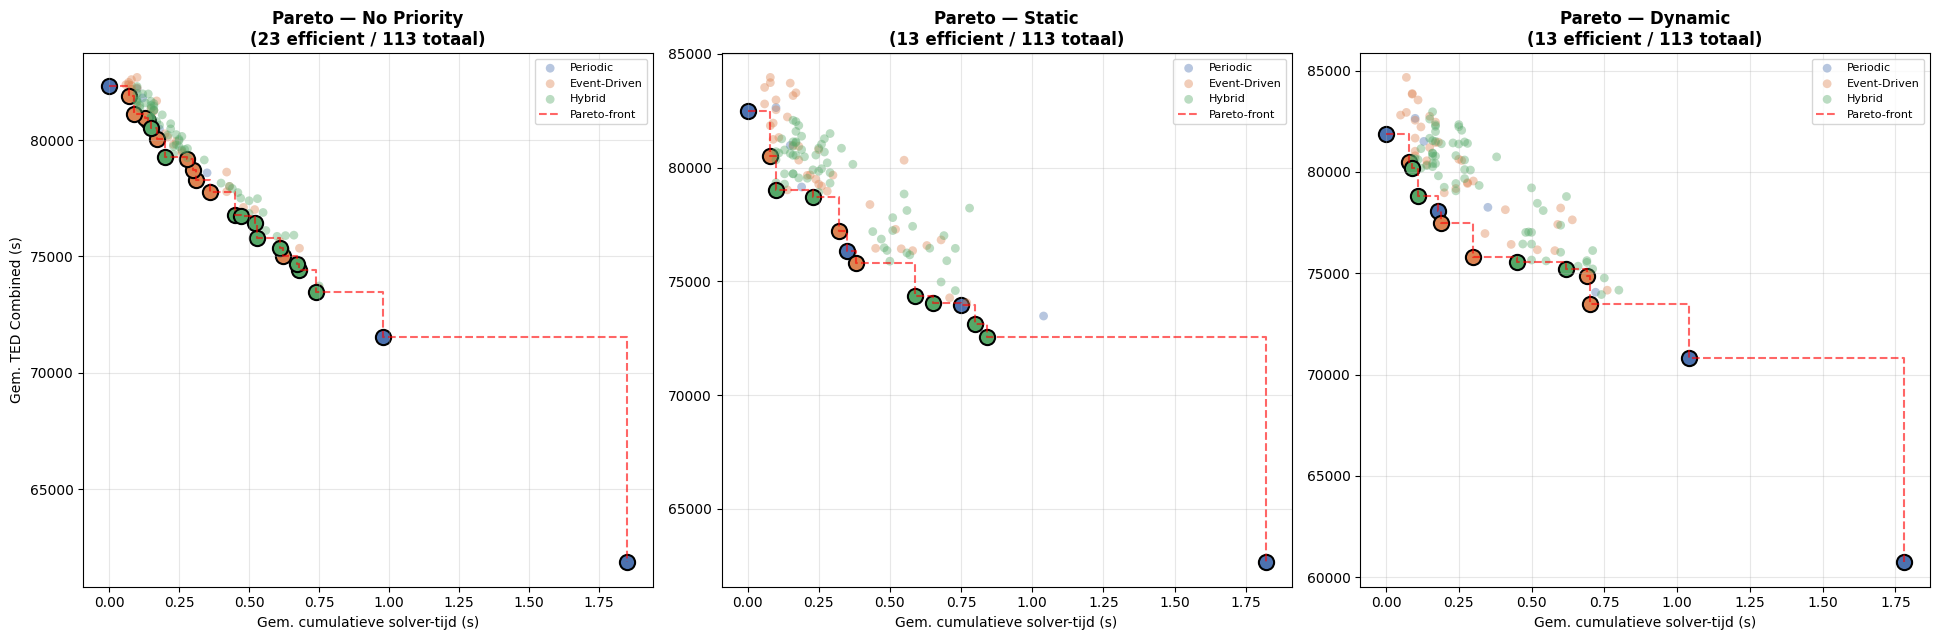


Pareto-efficiente configs per priority opgeslagen: /Users/ddw/Desktop/Rescheduling/results/fase1_full_extreme_weights_5/pareto_efficient.csv

Aantal Pareto-efficiente configs per priority:


,n_pareto
priority,
no_priority,23
static,13
dynamic,13


In [18]:
def is_pareto_efficient(df, x_col, y_col):
    """Boolean array — True als rij Pareto-efficiënt is (beide minimaliseren)."""
    vals = df[[x_col, y_col]].values
    effs = []
    for i, (xi, yi) in enumerate(vals):
        dominated = any(
            vals[j, 0] <= xi and vals[j, 1] <= yi and
            (vals[j, 0] < xi or vals[j, 1] < yi)
            for j in range(len(vals)) if j != i
        )
        effs.append(not dominated)
    return effs


fig, axes = plt.subplots(1, len(PRIORITY_ORDER), figsize=(6.5*len(PRIORITY_ORDER), 6.5), sharey=False)
if len(PRIORITY_ORDER) == 1:
    axes = [axes]

pareto_records = []

for ax, priority in zip(axes, PRIORITY_ORDER):
    sub = per_combo[per_combo["priority"] == priority].copy()
    if sub.empty:
        ax.axis("off"); continue

    sub["pareto"] = is_pareto_efficient(sub, "solve_time_mean", "TED_combined_mean")
    pareto_records.append(sub)

    # Plot per strategie
    for strat in TRIGGER_ORDER:
        s = sub[sub["strategy_type"] == strat]
        non_p = s[~s["pareto"]]
        p_eff = s[s["pareto"]]
        if not non_p.empty:
            ax.scatter(non_p["solve_time_mean"], non_p["TED_combined_mean"],
                       c=TRIGGER_COLORS[strat], alpha=0.4, s=40, edgecolors="none",
                       label=f"{TRIGGER_LABELS[strat]}")
        if not p_eff.empty:
            ax.scatter(p_eff["solve_time_mean"], p_eff["TED_combined_mean"],
                       c=TRIGGER_COLORS[strat], alpha=1.0, s=120,
                       edgecolors="black", linewidths=1.5)

    # Pareto-front lijn
    pf = sub[sub["pareto"]].sort_values("solve_time_mean")
    if len(pf) > 1:
        ax.step(pf["solve_time_mean"], pf["TED_combined_mean"],
                where="post", color="red", linestyle="--", linewidth=1.5,
                alpha=0.6, label="Pareto-front")

    ax.set_xlabel("Gem. cumulatieve solver-tijd (s)")
    ax.set_ylabel("Gem. TED Combined (s)" if priority == PRIORITY_ORDER[0] else "")
    ax.set_title(f"Pareto — {PRIORITY_LABELS[priority]}\n"
                 f"({sub['pareto'].sum()} efficient / {len(sub)} totaal)",
                 fontweight="bold")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.savefig(FIG_DIR / "pareto_per_priority.png", dpi=150, bbox_inches="tight")
plt.show()

# Pareto-efficiente configs als tabel opslaan
if pareto_records:
    pareto_all = pd.concat(pareto_records, ignore_index=True)
    pareto_eff = pareto_all[pareto_all["pareto"]].sort_values(["priority", "TED_combined_mean"])
    pareto_eff.to_csv(RESULTS_DIR / "pareto_efficient.csv", index=False)
    print(f"\nPareto-efficiente configs per priority opgeslagen: {RESULTS_DIR / 'pareto_efficient.csv'}")
    print(f"\nAantal Pareto-efficiente configs per priority:")
    display(pareto_eff.groupby("priority").size().to_frame("n_pareto"))


### 6.8 Interactie — welke timing-config profiteert het meest van priority?

Voor elke timing-config: bereken `Δ = TED_combined(no_priority) − TED_combined(static)` en idem voor dynamic. Een grote positieve Δ betekent dat priority **veel** verbetert in die setting; een negatieve Δ dat priority **schaadt**.

In [19]:
# ── Verschil tussen priorities binnen elke timing-config ──────────────────
key_cols = ["strategy_type", "periodic_rf", "event_driven_rf",
            "controller_freq", "threshold_conf"]

pivot_ted = per_combo.pivot_table(
    index=key_cols, columns="priority", values="TED_combined_mean", dropna=False
)
pivot_ted.columns = [f"TED_{c}" for c in pivot_ted.columns]

# Delta's
if "TED_no_priority" in pivot_ted.columns and "TED_static" in pivot_ted.columns:
    pivot_ted["delta_static"] = pivot_ted["TED_no_priority"] - pivot_ted["TED_static"]
if "TED_no_priority" in pivot_ted.columns and "TED_dynamic" in pivot_ted.columns:
    pivot_ted["delta_dynamic"] = pivot_ted["TED_no_priority"] - pivot_ted["TED_dynamic"]
if "TED_static" in pivot_ted.columns and "TED_dynamic" in pivot_ted.columns:
    pivot_ted["delta_dynamic_vs_static"] = pivot_ted["TED_static"] - pivot_ted["TED_dynamic"]

pivot_ted = pivot_ted.reset_index().round(1)
print("Verschil-tabel (positief = priority verbetert TED, negatief = priority verergert):")
print(f"\nTop-10 timing-configs waar Static priority het MEEST helpt vs. no_priority:")
if "delta_static" in pivot_ted.columns:
    display(pivot_ted.nlargest(10, "delta_static")[
        key_cols + ["TED_no_priority", "TED_static", "delta_static"]
    ])

print(f"\nTop-10 timing-configs waar Dynamic priority het MEEST helpt vs. no_priority:")
if "delta_dynamic" in pivot_ted.columns:
    display(pivot_ted.nlargest(10, "delta_dynamic")[
        key_cols + ["TED_no_priority", "TED_dynamic", "delta_dynamic"]
    ])

print(f"\nTop-10 timing-configs waar priority HET MEEST schaadt (alle priorities lager dan no_priority):")
if "delta_static" in pivot_ted.columns:
    display(pivot_ted.nsmallest(10, "delta_static")[
        key_cols + ["TED_no_priority", "TED_static", "delta_static"]
    ])


Verschil-tabel (positief = priority verbetert TED, negatief = priority verergert):

Top-10 timing-configs waar Static priority het MEEST helpt vs. no_priority:


,strategy_type,periodic_rf,event_driven_rf,controller_freq,threshold_conf,TED_no_priority,TED_static,delta_static
1565,hybrid,7200,5400,900,0.8,82303.3,79342.8,2960.5
1564,hybrid,7200,5400,900,0.6,81671.3,79016.4,2654.9
1548,hybrid,7200,3600,3600,0.4,81599.5,79280.0,2319.6
2017,periodic,1800,900,300,0.6,78591.9,76359.3,2232.6
1544,hybrid,7200,3600,900,0.8,81668.9,79551.4,2117.6
1290,hybrid,3600,900,900,0.4,77921.3,75892.0,2029.3
1566,hybrid,7200,5400,1800,0.4,81740.1,79731.7,2008.4
766,event_driven,100000,900,900,0.6,77756.0,75821.4,1934.6
1162,hybrid,1800,600,600,0.6,75864.0,74034.7,1829.2
811,event_driven,100000,3600,1800,0.6,80825.2,79026.1,1799.1



Top-10 timing-configs waar Dynamic priority het MEEST helpt vs. no_priority:


,strategy_type,periodic_rf,event_driven_rf,controller_freq,threshold_conf,TED_no_priority,TED_dynamic,delta_dynamic
1566,hybrid,7200,5400,1800,0.4,81740.1,78813.5,2926.6
788,event_driven,100000,1800,900,0.8,80127.4,77459.4,2668.1
1291,hybrid,3600,900,900,0.6,78153.3,75540.0,2613.2
767,event_driven,100000,900,900,0.8,78294.4,75812.0,2482.4
2122,periodic,3600,900,300,0.6,80473.8,78047.7,2426.1
761,event_driven,100000,900,450,0.8,78625.5,76423.6,2201.9
1565,hybrid,7200,5400,900,0.8,82303.3,80192.7,2110.6
736,event_driven,100000,600,300,0.6,75351.2,73494.7,1856.5
743,event_driven,100000,600,600,0.8,78010.0,76157.5,1852.6
1421,hybrid,5400,1800,1800,0.8,81085.3,79243.7,1841.6



Top-10 timing-configs waar priority HET MEEST schaadt (alle priorities lager dan no_priority):


,strategy_type,periodic_rf,event_driven_rf,controller_freq,threshold_conf,TED_no_priority,TED_static,delta_static
759,event_driven,100000,900,450,0.4,77014.0,80330.3,-3316.3
809,event_driven,100000,3600,900,0.8,81350.0,83718.7,-2368.6
1311,hybrid,3600,1800,900,0.4,79237.9,81503.0,-2265.1
1285,hybrid,3600,900,450,0.6,76753.1,78845.0,-2091.9
808,event_driven,100000,3600,900,0.6,81254.0,83293.3,-2039.4
1807,periodic,600,900,300,0.6,71545.0,73481.8,-1936.9
1261,hybrid,3600,600,300,0.6,74660.3,76456.1,-1795.8
815,event_driven,100000,3600,3600,0.8,81907.8,83528.9,-1621.2
835,event_driven,100000,5400,3600,0.6,82387.4,83971.2,-1583.9
1439,hybrid,5400,3600,900,0.8,80525.9,82085.8,-1559.8


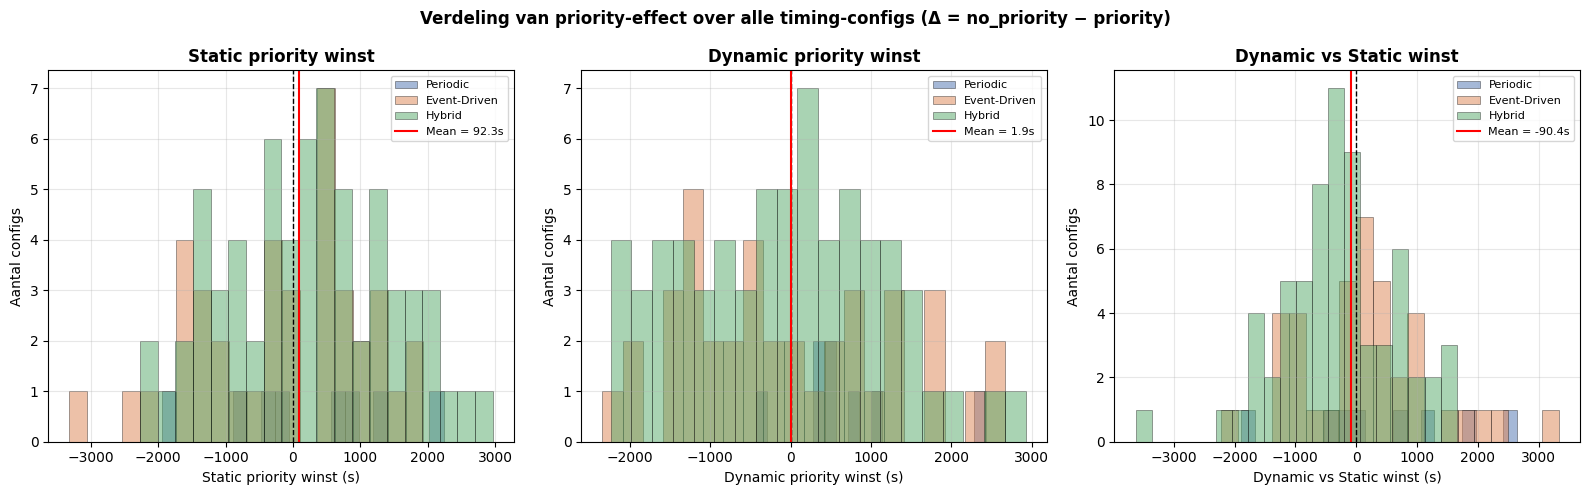

In [20]:
# ── Visualisatie van de interactie: histogram van delta's ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Verdeling van priority-effect over alle timing-configs (Δ = no_priority − priority)",
             fontsize=12, fontweight="bold")

delta_specs = [
    ("delta_static",              "Static priority winst (s)",        axes[0]),
    ("delta_dynamic",             "Dynamic priority winst (s)",       axes[1]),
    ("delta_dynamic_vs_static",   "Dynamic vs Static winst (s)",      axes[2]),
]

for col, label, ax in delta_specs:
    if col not in pivot_ted.columns:
        ax.set_title(f"{label}\n(niet beschikbaar)"); ax.axis("off"); continue
    vals = pivot_ted[col].dropna()
    if vals.empty:
        continue

    # Histogram met kleurcode per strategie
    for strat in TRIGGER_ORDER:
        v = pivot_ted[pivot_ted["strategy_type"] == strat][col].dropna()
        if len(v) > 0:
            ax.hist(v, bins=20, alpha=0.5, label=TRIGGER_LABELS[strat],
                    color=TRIGGER_COLORS[strat], edgecolor="black", linewidth=0.5)

    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.axvline(vals.mean(), color="red", linestyle="-", linewidth=1.5,
               label=f"Mean = {vals.mean():.1f}s")
    ax.set_xlabel(label)
    ax.set_ylabel("Aantal configs")
    ax.set_title(label.replace(" (s)", ""), fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "priority_interaction.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.9 Statistische tests

**A.** Hoofdeffect van **priority** (Kruskal-Wallis, geaggregeerd binnen elk trigger-type, met alle timing-configs samengevoegd).
**B.** Hoofdeffect van **trigger-type** (Kruskal-Wallis, binnen elke priority).
**C.** Post-hoc pairwise Mann-Whitney met Bonferroni.

In [21]:
TEST_METRICS = ["TED_combined", "TED_passenger", "TED_freight", "delay_ratio"]
ALPHA = 0.05

def bonferroni_mw(groups, labels, alpha=0.05):
    pairs = list(combinations(range(len(groups)), 2))
    n_comp = len(pairs)
    rows_mw = []
    for i, j in pairs:
        g1, g2 = groups[i], groups[j]
        if len(g1) < 2 or len(g2) < 2:
            continue
        stat, p_raw = mannwhitneyu(g1, g2, alternative="two-sided")
        p_adj = min(p_raw * n_comp, 1.0)
        rows_mw.append({
            "group_A": labels[i], "group_B": labels[j],
            "U_stat": round(stat, 1),
            "p_raw":  round(p_raw, 4),
            "p_bonf": round(p_adj, 4),
            "sig":    "✓" if p_adj < alpha else "",
        })
    return pd.DataFrame(rows_mw)


print("=" * 70)
print("A. EFFECT VAN PRIORITY (Kruskal-Wallis per trigger-type)")
print("=" * 70)

for metric in TEST_METRICS:
    if metric not in raw.columns: continue
    print(f"\n--- {metric} ---")
    for trigger in TRIGGER_ORDER:
        groups = [
            raw[(raw["trigger"] == trigger) & (raw["priority"] == p)][metric].dropna().values
            for p in PRIORITY_ORDER
        ]
        valid = [g for g in groups if len(g) >= 2]
        if len(valid) < 2:
            print(f"  {trigger}: onvoldoende data")
            continue
        stat, p_val = kruskal(*valid)
        sig = "*** p<.001" if p_val < .001 else ("** p<.01" if p_val < .01 else ("* p<.05" if p_val < .05 else "ns"))
        print(f"  {trigger:<15}  H={stat:7.2f}  p={p_val:.4f}  {sig}")


A. EFFECT VAN PRIORITY (Kruskal-Wallis per trigger-type)

--- TED_combined ---
  periodic         H=  10.66  p=0.0048  ** p<.01
  event_driven     H=   0.28  p=0.8694  ns
  hybrid           H=   1.39  p=0.4992  ns

--- TED_passenger ---
  periodic         H=  13.96  p=0.0009  *** p<.001
  event_driven     H=   1.29  p=0.5250  ns
  hybrid           H=   2.91  p=0.2337  ns

--- TED_freight ---
  periodic         H=   0.06  p=0.9690  ns
  event_driven     H=   0.19  p=0.9089  ns
  hybrid           H=   9.91  p=0.0071  ** p<.01

--- delay_ratio ---
  periodic         H=   6.89  p=0.0319  * p<.05
  event_driven     H=   1.32  p=0.5165  ns
  hybrid           H=  12.52  p=0.0019  ** p<.01


In [22]:
print("=" * 70)
print("B. EFFECT VAN TRIGGER-TYPE (Kruskal-Wallis per priority)")
print("=" * 70)

for metric in TEST_METRICS:
    if metric not in raw.columns: continue
    print(f"\n--- {metric} ---")
    for priority in PRIORITY_ORDER:
        groups = [
            raw[(raw["trigger"] == t) & (raw["priority"] == priority)][metric].dropna().values
            for t in TRIGGER_ORDER
        ]
        valid = [g for g in groups if len(g) >= 2]
        if len(valid) < 2:
            continue
        stat, p_val = kruskal(*valid)
        sig = "*** p<.001" if p_val < .001 else ("** p<.01" if p_val < .01 else ("* p<.05" if p_val < .05 else "ns"))
        print(f"  {priority:<15}  H={stat:7.2f}  p={p_val:.4f}  {sig}")

print()
print("=" * 70)
print("C. POST-HOC PAIRWISE — priority binnen elke trigger-type")
print("   (Mann-Whitney + Bonferroni, α = 0.05)")
print("=" * 70)

for metric in ["TED_combined", "delay_ratio"]:
    if metric not in raw.columns: continue
    print(f"\n=== {metric} ===")
    for trigger in TRIGGER_ORDER:
        groups = [
            raw[(raw["trigger"] == trigger) & (raw["priority"] == p)][metric].dropna().values
            for p in PRIORITY_ORDER
        ]
        df_mw = bonferroni_mw(groups, PRIORITY_ORDER)
        if df_mw.empty: continue
        print(f"\n  Trigger: {TRIGGER_LABELS[trigger]}")
        display(df_mw)


B. EFFECT VAN TRIGGER-TYPE (Kruskal-Wallis per priority)

--- TED_combined ---
  no_priority      H=  51.87  p=0.0000  *** p<.001
  static           H=   9.13  p=0.0104  * p<.05
  dynamic          H=  11.19  p=0.0037  ** p<.01

--- TED_passenger ---
  no_priority      H=  61.97  p=0.0000  *** p<.001
  static           H=  19.66  p=0.0001  *** p<.001
  dynamic          H=  13.66  p=0.0011  ** p<.01

--- TED_freight ---
  no_priority      H=   1.65  p=0.4382  ns
  static           H=   4.16  p=0.1250  ns
  dynamic          H=   7.65  p=0.0219  * p<.05

--- delay_ratio ---
  no_priority      H=  33.91  p=0.0000  *** p<.001
  static           H=  14.94  p=0.0006  *** p<.001
  dynamic          H=  17.66  p=0.0001  *** p<.001

C. POST-HOC PAIRWISE — priority binnen elke trigger-type
   (Mann-Whitney + Bonferroni, α = 0.05)

=== TED_combined ===

  Trigger: Periodic


,group_A,group_B,U_stat,p_raw,p_bonf,sig
0,no_priority,static,11666.0,0.0021,0.0063,✓
1,no_priority,dynamic,8456.0,0.4635,1.0000,
2,static,dynamic,1957.5,0.0111,0.0334,✓



  Trigger: Event-Driven


,group_A,group_B,U_stat,p_raw,p_bonf,sig
0,no_priority,static,182487.0,0.6019,1.0,
1,no_priority,dynamic,186577.5,0.8917,1.0,
2,static,dynamic,19230.0,0.7767,1.0,



  Trigger: Hybrid


...

,group_A,group_B,U_stat,p_raw,p_bonf,sig
0,no_priority,static,17815.0,0.0099,0.0296,✓
1,no_priority,dynamic,7756.0,0.8498,1.0000,
2,static,dynamic,1214.5,0.0765,0.2294,



  Trigger: Event-Driven


,group_A,group_B,U_stat,p_raw,p_bonf,sig
0,no_priority,static,192065.5,0.5109,1.0000,
1,no_priority,dynamic,195801.0,0.3192,0.9577,
2,static,dynamic,19269.0,0.7499,1.0000,



  Trigger: Hybrid


,group_A,group_B,U_stat,p_raw,p_bonf,sig
0,no_priority,static,482698.5,0.0116,0.0349,✓
1,no_priority,dynamic,481121.5,0.0069,0.0208,✓
2,static,dynamic,52448.5,0.9329,1.0000,


### 6.10 Delay Ratio — diepteanalyse

DR > 1 → freight-treinen dragen meer eindvertraging per trein dan passagierstreinen (freight benadeeld).
DR < 1 → freight-treinen hebben minder eindvertraging.

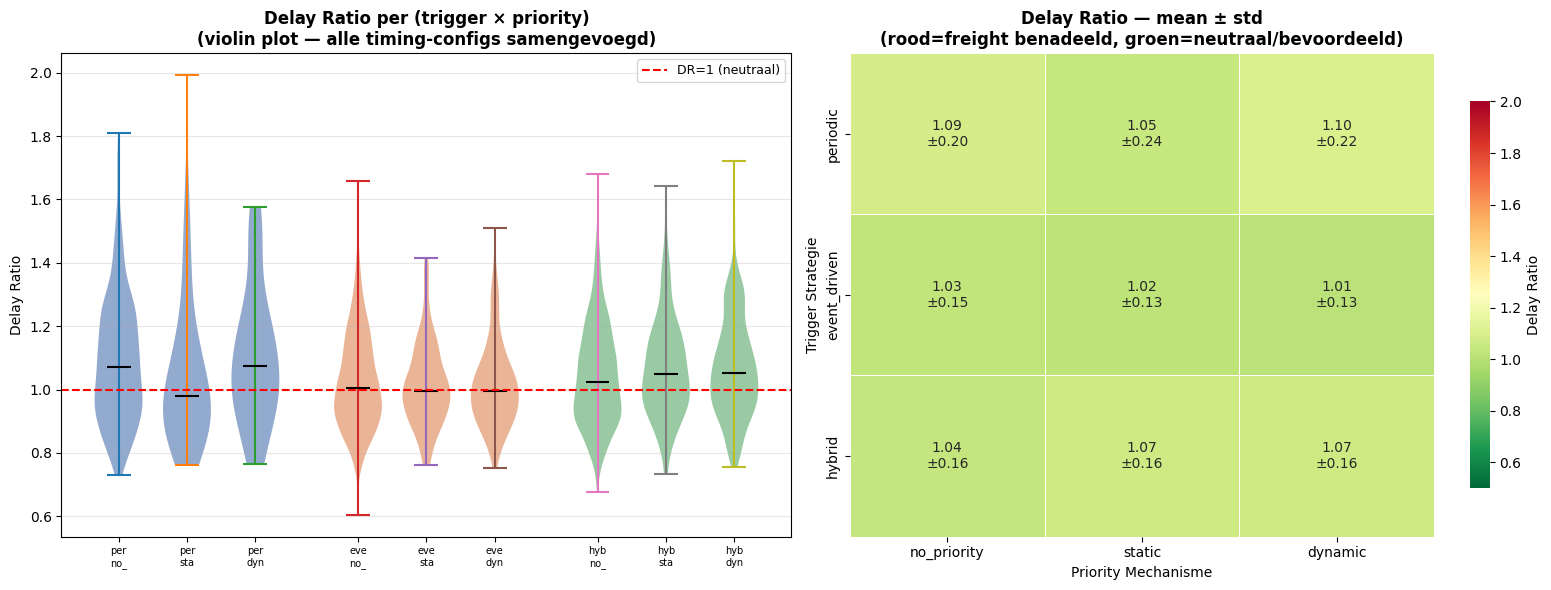

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Links: violin plot per (trigger × priority) ────────────────────────────
ax = axes[0]
positions, tick_labels = [], []
pos = 0
for trigger in TRIGGER_ORDER:
    for priority in PRIORITY_ORDER:
        vals = raw[(raw["trigger"] == trigger) & (raw["priority"] == priority)]["delay_ratio"].dropna().values
        if len(vals) > 1:
            vp = ax.violinplot(vals, positions=[pos], widths=0.7,
                               showmedians=True, showextrema=True)
            for pc in vp["bodies"]:
                pc.set_facecolor(TRIGGER_COLORS[trigger]); pc.set_alpha(0.6)
            vp["cmedians"].set_color("black")
        positions.append(pos)
        tick_labels.append(f"{trigger[:3]}\n{priority[:3]}")
        pos += 1
    pos += 0.5

ax.axhline(1.0, color="red", linestyle="--", linewidth=1.5, label="DR=1 (neutraal)")
ax.set_xticks(positions)
ax.set_xticklabels(tick_labels, fontsize=7)
ax.set_ylabel("Delay Ratio")
ax.set_title("Delay Ratio per (trigger × priority)\n(violin plot — alle timing-configs samengevoegd)",
             fontweight="bold")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)

# ── Rechts: heatmap met mean ± std ─────────────────────────────────────────
ax2 = axes[1]
dr_mean = (raw.groupby(["trigger","priority"], observed=True)["delay_ratio"]
             .mean().unstack("priority")
             .reindex(index=TRIGGER_ORDER, columns=PRIORITY_ORDER))
dr_std  = (raw.groupby(["trigger","priority"], observed=True)["delay_ratio"]
             .std().unstack("priority")
             .reindex(index=TRIGGER_ORDER, columns=PRIORITY_ORDER))

annot_text = dr_mean.copy().astype(object)
for r in TRIGGER_ORDER:
    for c in PRIORITY_ORDER:
        m, s = dr_mean.loc[r, c], dr_std.loc[r, c]
        annot_text.loc[r, c] = f"{m:.2f}\n±{s:.2f}" if pd.notna(m) else "—"

sns.heatmap(dr_mean, ax=ax2, cmap="RdYlGn_r", annot=annot_text, fmt="",
            linewidths=0.5, linecolor="white",
            vmin=0.5, vmax=max(2.0, dr_mean.max().max() + 0.2),
            cbar_kws={"label": "Delay Ratio", "shrink": 0.8})
ax2.set_title("Delay Ratio — mean ± std\n(rood=freight benadeeld, groen=neutraal/bevoordeeld)",
              fontweight="bold")
ax2.set_xlabel("Priority Mechanisme"); ax2.set_ylabel("Trigger Strategie")

plt.tight_layout()
plt.savefig(FIG_DIR / "delay_ratio_deep.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.11 Solver effort — n_rescheduled & total_solve_time

Hoeveel werk doet de solver, en weegt dat tegen de winst op?

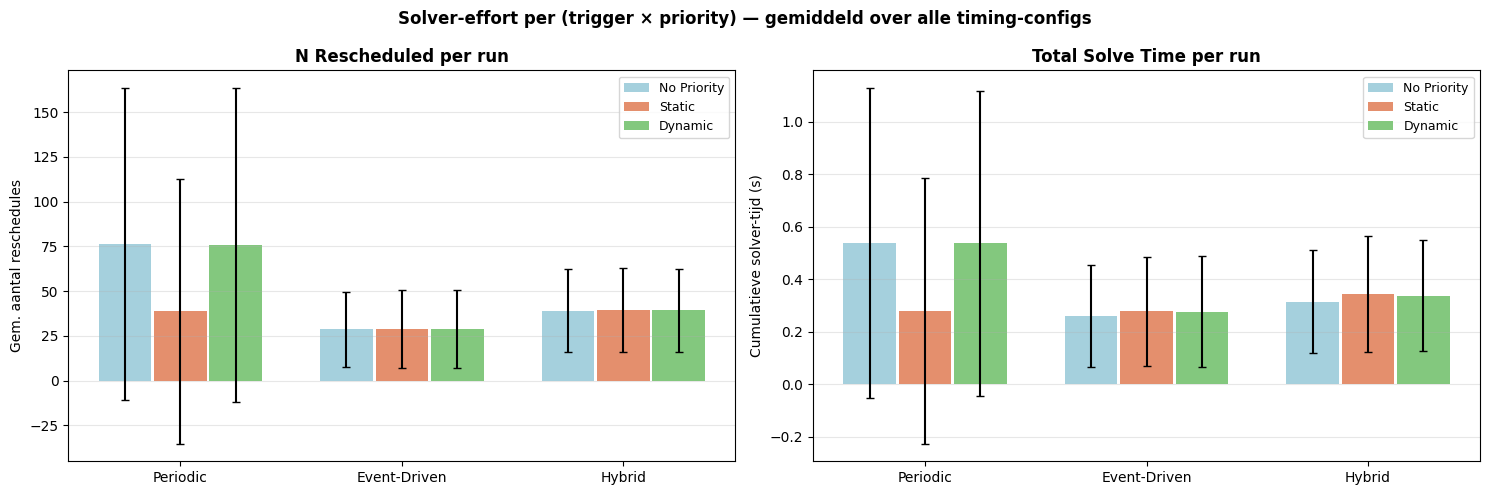

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Solver-effort per (trigger × priority) — gemiddeld over alle timing-configs",
             fontsize=12, fontweight="bold")

x = np.arange(len(TRIGGER_ORDER))
width = 0.25

# n_rescheduled
ax = axes[0]
for i, priority in enumerate(PRIORITY_ORDER):
    vals = [raw[(raw["trigger"]==t) & (raw["priority"]==priority)]["n_rescheduled"].mean()
            for t in TRIGGER_ORDER]
    stds = [raw[(raw["trigger"]==t) & (raw["priority"]==priority)]["n_rescheduled"].std()
            for t in TRIGGER_ORDER]
    offset = (i - 1) * width
    ax.bar(x + offset, vals, width=width*0.95, yerr=stds, capsize=3,
           label=PRIORITY_LABELS[priority], alpha=0.85,
           color=PRIORITY_COLORS[priority])

ax.set_xticks(x); ax.set_xticklabels([TRIGGER_LABELS[t] for t in TRIGGER_ORDER])
ax.set_ylabel("Gem. aantal reschedules")
ax.set_title("N Rescheduled per run", fontweight="bold")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)

# total_solve_time
ax = axes[1]
for i, priority in enumerate(PRIORITY_ORDER):
    vals = [raw[(raw["trigger"]==t) & (raw["priority"]==priority)]["total_solve_time"].mean()
            for t in TRIGGER_ORDER]
    stds = [raw[(raw["trigger"]==t) & (raw["priority"]==priority)]["total_solve_time"].std()
            for t in TRIGGER_ORDER]
    offset = (i - 1) * width
    ax.bar(x + offset, vals, width=width*0.95, yerr=stds, capsize=3,
           label=PRIORITY_LABELS[priority], alpha=0.85,
           color=PRIORITY_COLORS[priority])

ax.set_xticks(x); ax.set_xticklabels([TRIGGER_LABELS[t] for t in TRIGGER_ORDER])
ax.set_ylabel("Cumulatieve solver-tijd (s)")
ax.set_title("Total Solve Time per run", fontweight="bold")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "solver_effort.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.12 Infeasibility & FCFS-fallback

Hoe vaak faalt de MIP en valt het systeem terug op FCFS?

In [25]:
if "infeasible_run" in raw_all.columns:
    inf_tbl = raw_all.groupby(["strategy_type", "priority"], dropna=False).agg(
        n_runs          = ("seed",            "count"),
        n_infeasible    = ("infeasible_run",  "sum"),
        pct_infeasible  = ("infeasible_run",  lambda x: 100 * x.sum() / len(x)),
        n_fcfs_fallback = ("n_fcfs_fallback", "mean") if "n_fcfs_fallback" in raw_all.columns else ("seed", "count"),
    ).round(2)
    print("Infeasibility per (trigger × priority):")
    display(inf_tbl)

    total_inf = raw_all["infeasible_run"].sum()
    if total_inf == 0:
        print("\n✓ Geen infeasible MIP-oplossingen.")
    else:
        print(f"\n⚠ {int(total_inf)} runs hadden een FCFS fallback.")
else:
    print("Kolom 'infeasible_run' niet aanwezig — sla over.")

# Deadlock-overzicht
if "deadlock" in raw_all.columns:
    dl_tbl = (raw_all.groupby(["strategy_type", "priority"])["deadlock"]
                     .apply(lambda x: int(x.fillna(False).astype(bool).sum()))
                     .unstack("priority")
                     .reindex(index=TRIGGER_ORDER, columns=PRIORITY_ORDER))
    print("\nAantal deadlocks per (trigger × priority):")
    display(dl_tbl)


Infeasibility per (trigger × priority):


n_runs  n_infeasible  pct_infeasible  \
strategy_type priority                                            
event_driven  dynamic         195             0             0.0   
              no_priority    1950             0             0.0   
              static          195             0             0.0   
hybrid        dynamic         330             0             0.0   
              no_priority    3300             0             0.0   
              static          330             0             0.0   
periodic      dynamic          40             0             0.0   
              no_priority     400             0             0.0   
              static           77             0             0.0   

                           n_fcfs_fallback  
strategy_type priority                      
event_driven  dynamic                  0.0  
              no_priority              0.0  
              static                   0.0  
hybrid        dynamic                  0.0  
              no_priority              0.0  
              static                   0.0  
periodic      dynamic                  0.0  
              no_priority              0.0  
              static                   0.0


✓ Geen infeasible MIP-oplossingen.

Aantal deadlocks per (trigger × priority):


priority,no_priority,static,dynamic
strategy_type,,,
periodic,5,1,0
event_driven,25,1,0
hybrid,44,6,5


### 6.13 Top-N globale ranking

Welke individuele (timing × priority) combinaties scoren globaal het best?

In [26]:
top_n = 20
top_overall = per_combo.sort_values("TED_combined_mean").head(top_n).copy()
top_overall["rank"] = range(1, len(top_overall)+1)

cols_show = ["rank", "strategy_type", "priority", "periodic_rf", "event_driven_rf",
             "controller_freq", "threshold_conf",
             "TED_combined_mean", "TED_combined_std",
             "TED_passenger_mean", "TED_freight_mean",
             "delay_ratio_mean", "solve_time_mean", "n_seeds"]
cols_show = [c for c in cols_show if c in top_overall.columns]

print(f"Top-{top_n} configs op TED_combined_mean (laagst eerst):")
display(top_overall[cols_show])

# Slechtste top-N (voor contrast)
worst_n = 10
worst_overall = per_combo.sort_values("TED_combined_mean", ascending=False).head(worst_n).copy()
worst_overall["rank_from_bottom"] = range(1, len(worst_overall)+1)
print(f"\nSlechtste {worst_n} configs op TED_combined_mean:")
display(worst_overall[["rank_from_bottom"] + cols_show[1:]])

# Beste configs ook geannoteerd opslaan
top_overall.to_csv(RESULTS_DIR / f"top{top_n}_configs.csv", index=False)
print(f"\nOpgeslagen: top{top_n}_configs.csv")


Top-20 configs op TED_combined_mean (laagst eerst):


,rank,strategy_type,priority,periodic_rf,event_driven_rf,controller_freq,threshold_conf,TED_combined_mean,TED_combined_std,TED_passenger_mean,TED_freight_mean,delay_ratio_mean,solve_time_mean,n_seeds
317,1,periodic,dynamic,300,900,300,0.6,60732.18,2520.54,48224.06,12508.12,1.47,1.78,5
315,2,periodic,no_priority,300,900,300,0.6,61847.36,3072.18,49489.01,12358.35,1.41,1.85,50
316,3,periodic,static,300,900,300,0.6,62648.42,2724.31,48529.84,14118.58,1.65,1.82,5
320,4,periodic,dynamic,600,900,300,0.6,70834.44,569.38,57471.36,13363.08,1.32,1.04,5
318,5,periodic,no_priority,600,900,300,0.6,71544.95,3013.62,59162.18,12382.76,1.18,0.98,50
154,6,hybrid,static,3600,600,300,0.4,72572.88,1259.60,60031.88,12541.00,1.18,0.84,5
118,7,hybrid,static,1800,600,300,0.4,73121.74,3885.37,60049.06,13072.68,1.23,0.80,5
117,8,hybrid,no_priority,1800,600,300,0.4,73473.50,3097.32,60684.06,12789.44,1.19,0.74,50
319,9,periodic,static,600,900,300,0.6,73481.83,3236.98,58817.79,14664.04,1.41,1.04,5
5,10,event_driven,dynamic,100000,600,300,0.6,73494.70,3622.76,60727.58,12767.12,1.19,0.70,5



Slechtste 10 configs op TED_combined_mean:


,rank_from_bottom,strategy_type,priority,periodic_rf,event_driven_rf,controller_freq,threshold_conf,TED_combined_mean,TED_combined_std,TED_passenger_mean,TED_freight_mean,delay_ratio_mean,solve_time_mean,n_seeds
86,1,event_driven,dynamic,100000,3600,3600,0.6,84662.62,1550.60,72281.32,12381.30,0.97,0.07,5
103,2,event_driven,static,100000,5400,3600,0.6,83971.22,1875.28,71283.14,12688.08,1.01,0.08,5
104,3,event_driven,dynamic,100000,5400,3600,0.6,83865.00,1764.37,71074.66,12790.34,1.02,0.09,5
83,4,event_driven,dynamic,100000,3600,3600,0.4,83833.76,3601.51,71794.36,12039.40,0.95,0.09,5
85,5,event_driven,static,100000,3600,3600,0.6,83740.94,3109.65,71153.96,12586.98,1.00,0.08,5
70,6,event_driven,static,100000,3600,900,0.8,83718.66,2926.22,71222.36,12496.30,0.99,0.15,5
92,7,event_driven,dynamic,100000,5400,1800,0.4,83547.36,4830.00,71485.34,12062.02,0.96,0.11,5
88,8,event_driven,static,100000,3600,3600,0.8,83528.94,3603.70,71105.96,12422.98,0.99,0.06,5
67,9,event_driven,static,100000,3600,900,0.6,83293.34,2385.71,70983.52,12309.82,0.98,0.17,5
64,10,event_driven,static,100000,3600,900,0.4,83171.20,2370.92,70375.68,12795.52,1.03,0.16,5



Opgeslagen: top20_configs.csv


### 6.14 Sensitiviteits-analyse — welke parameter veroorzaakt meeste variantie?

Voor elke timing-parameter: groepeer alle runs op die parameter en bereken de tussen-groep variantie van `TED_combined_mean`. Hoe groter de tussen-groep variantie, des te sterker het effect van die parameter.

Sensitiviteit (tussen-groep std op TED_combined, in seconden):
Hogere waarde = parameter heeft groter effect.



priority,ALL,dynamic,no_priority,static
parameter,,,,
controller_freq,70420.5,21258.1,65889.2,16336.1
event_driven_rf,93864.0,28082.3,86697.4,24349.9
periodic_rf,75147.2,22426.7,68756.9,20948.6
priority,2080.3,NaN,NaN,NaN
strategy_type,40216.6,15437.9,39994.1,7670.8
threshold_conf,19123.8,6316.1,18940.7,1234.8


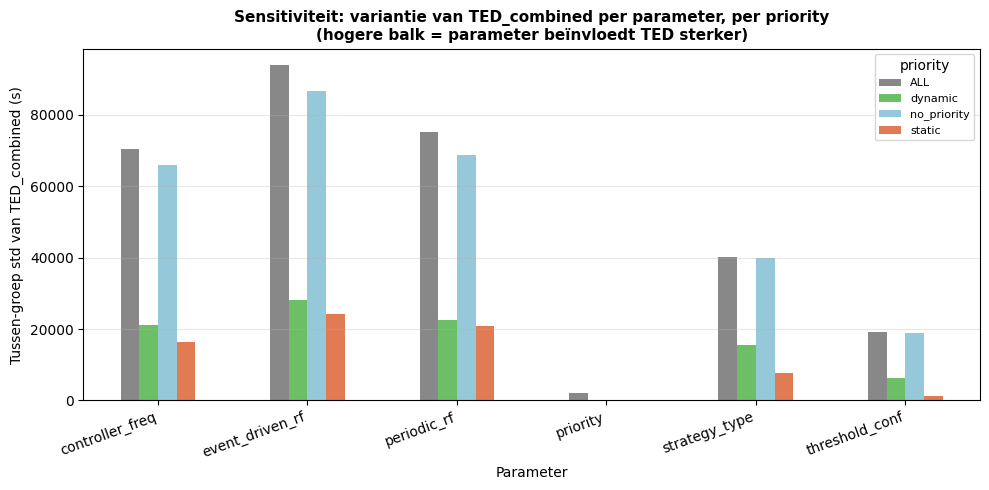

In [27]:
def between_group_variance(df, group_col, value_col):
    """Tussen-groep variantie van value_col, gegroepeerd op group_col."""
    if df[group_col].isna().all() or df[group_col].nunique() < 2:
        return np.nan, 0
    means = df.groupby(group_col, dropna=True)[value_col].mean()
    counts = df.groupby(group_col, dropna=True)[value_col].count()
    if len(means) < 2: return np.nan, 0
    grand_mean = (means * counts).sum() / counts.sum()
    bgv = ((counts * (means - grand_mean)**2).sum() / (len(means) - 1))
    return bgv, len(means)

PARAMS_TO_TEST = ["strategy_type", "periodic_rf", "event_driven_rf",
                  "controller_freq", "threshold_conf", "priority"]

results_sens = []
for priority in PRIORITY_ORDER:
    sub = raw[raw["priority"] == priority]
    for param in PARAMS_TO_TEST:
        if param not in sub.columns: continue
        bgv, n_groups = between_group_variance(sub, param, "TED_combined")
        results_sens.append({
            "priority":  priority,
            "parameter": param,
            "n_groups":  n_groups,
            "between_group_variance": bgv,
            "between_group_std":      np.sqrt(bgv) if pd.notna(bgv) else np.nan,
        })

# En zonder filteren op priority:
for param in PARAMS_TO_TEST:
    if param not in raw.columns: continue
    bgv, n_groups = between_group_variance(raw, param, "TED_combined")
    results_sens.append({
        "priority":  "ALL",
        "parameter": param,
        "n_groups":  n_groups,
        "between_group_variance": bgv,
        "between_group_std":      np.sqrt(bgv) if pd.notna(bgv) else np.nan,
    })

sens_df = pd.DataFrame(results_sens).round(2)
print("Sensitiviteit (tussen-groep std op TED_combined, in seconden):")
print("Hogere waarde = parameter heeft groter effect.\n")

# Per priority pivot
pivot_sens = sens_df.pivot(index="parameter", columns="priority", values="between_group_std")
display(pivot_sens.round(1))

# Visualisatie
fig, ax = plt.subplots(figsize=(10, 5))
pivot_sens.plot(kind="bar", ax=ax, color=[PRIORITY_COLORS.get(p, "#888") for p in pivot_sens.columns])
ax.set_ylabel("Tussen-groep std van TED_combined (s)")
ax.set_xlabel("Parameter")
ax.set_title("Sensitiviteit: variantie van TED_combined per parameter, per priority\n"
             "(hogere balk = parameter beïnvloedt TED sterker)",
             fontweight="bold", fontsize=11)
ax.grid(axis="y", alpha=0.3)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
plt.legend(title="priority", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.15 Geaggregeerde CSV opslaan

Zelfde aanpak als Fase1 — geaggregeerde stats per config-directory in één gecombineerde tabel.

In [28]:
agg_frames = []
errors_agg = []
for cfg_dir in sorted(RESULTS_DIR.iterdir()):
    if not cfg_dir.is_dir(): continue
    csv_path = cfg_dir / "raw_runs.csv"
    if csv_path.exists():
        try:
            agg = aggregate_config(cfg_dir)
            agg["config"] = cfg_dir.name
            agg_frames.append(agg)
        except Exception as e:
            errors_agg.append((cfg_dir.name, str(e)))

if agg_frames:
    agg_all = pd.concat(agg_frames, ignore_index=True)
    agg_all.to_csv(RESULTS_DIR / "all_aggregated.csv", index=False)
    print(f"Opgeslagen: all_aggregated.csv  ({len(agg_all)} configs)")
    show_cols = [c for c in ["config", "TED_combined_mean", "TED_combined_std",
                              "delay_ratio_mean", "delay_ratio_std",
                              "total_solve_time_mean", "n_rescheduled_mean"] if c in agg_all.columns]
    display(agg_all[show_cols].round(2).head(20))
    if len(agg_all) > 20:
        print(f"\n... ({len(agg_all)-20} meer configs in all_aggregated.csv)")

if errors_agg:
    print(f"\n⚠ Fouten bij aggregeren ({len(errors_agg)}):")
    for name, msg in errors_agg[:10]:
        print(f"  {name}: {msg}")


Opgeslagen: all_aggregated.csv  (339 configs)


,config,TED_combined_mean,TED_combined_std,delay_ratio_mean,delay_ratio_std,total_solve_time_mean,n_rescheduled_mean
0,baseline_dynamic,81864.30,3289.17,0.89,0.09,0.00,0.00
1,baseline_no_priority,82317.55,3474.48,0.95,0.13,0.00,0.00
2,baseline_static,82499.20,3550.18,0.95,0.13,0.00,0.00
3,event_driven_edf1800_cf1800_tc0.40_dynamic,80624.22,3936.80,1.07,0.13,0.25,25.40
4,event_driven_edf1800_cf1800_tc0.40_no_priority,79816.47,3936.03,1.01,0.16,0.23,24.66
5,event_driven_edf1800_cf1800_tc0.40_static,79277.18,2424.59,1.00,0.16,0.25,24.40
6,event_driven_edf1800_cf1800_tc0.60_dynamic,78969.78,3597.35,0.93,0.07,0.20,20.60
7,event_driven_edf1800_cf1800_tc0.60_no_priority,80269.71,3960.82,1.00,0.14,0.20,21.63
8,event_driven_edf1800_cf1800_tc0.60_static,79665.04,2713.97,1.04,0.14,0.21,20.40
9,event_driven_edf1800_cf1800_tc0.80_dynamic,81467.60,3038.26,0.91,0.07,0.18,18.20



... (319 meer configs in all_aggregated.csv)


### 6.16 Eindsamenvatting — key findings

Compacte tekst-output met de belangrijkste bevindingen voor je thesis.

In [29]:
print("=" * 70)
print(" EINDSAMENVATTING ")
print("=" * 70)

# 1. Beste config overall
best_overall = per_combo.sort_values("TED_combined_mean").iloc[0]
print(f"\n🏆 BESTE CONFIG OVERALL (op TED_combined_mean):")
print(f"   Trigger:               {best_overall['strategy_type']}")
print(f"   Priority:              {best_overall['priority']}")
print(f"   event_driven_freq:     {best_overall['event_driven_rf']}")
print(f"   controller_freq:       {best_overall['controller_freq']}")
print(f"   periodic_freq:         {best_overall['periodic_rf']}")
print(f"   threshold_conf:        {best_overall['threshold_conf']}")
print(f"   TED_combined_mean:     {best_overall['TED_combined_mean']:.1f}s  (std={best_overall['TED_combined_std']:.1f})")
print(f"   delay_ratio_mean:      {best_overall['delay_ratio_mean']:.3f}")
print(f"   solve_time_mean:       {best_overall['solve_time_mean']:.1f}s")

# 2. Beste config per priority
print(f"\n📌 BESTE CONFIG PER PRIORITY:")
for priority in PRIORITY_ORDER:
    sub = per_combo[per_combo["priority"] == priority]
    if sub.empty: continue
    b = sub.sort_values("TED_combined_mean").iloc[0]
    print(f"   {priority:<15}  {b['strategy_type']:<13}  edf={b['event_driven_rf']}, "
          f"cf={b['controller_freq']}, prf={b['periodic_rf']}, tc={b['threshold_conf']}  "
          f"→  TED={b['TED_combined_mean']:.1f}s, DR={b['delay_ratio_mean']:.2f}")

# 3. Trigger-type globaal
print(f"\n📊 GLOBAAL PER TRIGGER-TYPE (geaggregeerd):")
type_summary = raw.groupby("strategy_type").agg(
    n_runs            = ("seed",            "count"),
    n_configs         = ("config",          "nunique"),
    TED_combined_mean = ("TED_combined",    "mean"),
    delay_ratio_mean  = ("delay_ratio",     "mean"),
    solve_time_mean   = ("total_solve_time","mean"),
).round(1)
display(type_summary)

# 4. Priority winst (gemiddeld over alle timing-configs)
print(f"\n📈 GEM. WINST VAN PRIORITY (op TED_combined, in seconden):")
if "delta_static" in pivot_ted.columns:
    print(f"   Static vs No Priority:   {pivot_ted['delta_static'].mean():+.1f}s "
          f"(min={pivot_ted['delta_static'].min():+.1f}, max={pivot_ted['delta_static'].max():+.1f})")
if "delta_dynamic" in pivot_ted.columns:
    print(f"   Dynamic vs No Priority:  {pivot_ted['delta_dynamic'].mean():+.1f}s "
          f"(min={pivot_ted['delta_dynamic'].min():+.1f}, max={pivot_ted['delta_dynamic'].max():+.1f})")

# 5. Belangrijkste parameter
print(f"\n🔬 SENSITIVITEIT — parameter met grootste effect op TED_combined:")
sens_overall = sens_df[sens_df["priority"] == "ALL"].sort_values("between_group_std", ascending=False)
for _, r in sens_overall.iterrows():
    print(f"   {r['parameter']:<20}  std={r['between_group_std']:.1f}s  ({int(r['n_groups'])} groepen)")

print(f"\n{'=' * 70}")
print(f" Analyse compleet — resultaten in {RESULTS_DIR}")
print(f" Figuren in {FIG_DIR}")
print(f"{'=' * 70}")


 EINDSAMENVATTING 

🏆 BESTE CONFIG OVERALL (op TED_combined_mean):
   Trigger:               periodic
   Priority:              dynamic
   event_driven_freq:     900
   controller_freq:       300
   periodic_freq:         300
   threshold_conf:        0.6
   TED_combined_mean:     60732.2s  (std=2520.5)
   delay_ratio_mean:      1.470
   solve_time_mean:       1.8s

📌 BESTE CONFIG PER PRIORITY:
   no_priority      periodic       edf=900, cf=300, prf=300, tc=0.6  →  TED=61847.4s, DR=1.41
   static           periodic       edf=900, cf=300, prf=300, tc=0.6  →  TED=62648.4s, DR=1.65
   dynamic          periodic       edf=900, cf=300, prf=300, tc=0.6  →  TED=60732.2s, DR=1.47

📊 GLOBAAL PER TRIGGER-TYPE (geaggregeerd):


,n_runs,n_configs,TED_combined_mean,delay_ratio_mean,solve_time_mean
strategy_type,,,,,
event_driven,2314,117,79774.9,1.0,0.3
hybrid,3905,198,79172.1,1.0,0.3
periodic,511,24,77002.1,1.1,0.5



📈 GEM. WINST VAN PRIORITY (op TED_combined, in seconden):
   Static vs No Priority:   +92.3s (min=-3316.3, max=+2960.5)
   Dynamic vs No Priority:  +1.9s (min=-2342.6, max=+2926.6)

🔬 SENSITIVITEIT — parameter met grootste effect op TED_combined:
   event_driven_rf       std=93864.1s  (5 groepen)
   periodic_rf           std=75147.2s  (8 groepen)
   controller_freq       std=70420.5s  (7 groepen)
   strategy_type         std=40216.6s  (3 groepen)
   threshold_conf        std=19123.8s  (3 groepen)
   priority              std=2080.3s  (3 groepen)

 Analyse compleet — resultaten in /Users/ddw/Desktop/Rescheduling/results/fase1_full_extreme_weights_5
 Figuren in /Users/ddw/Desktop/Rescheduling/results/fase1_full_extreme_weights_5/figures


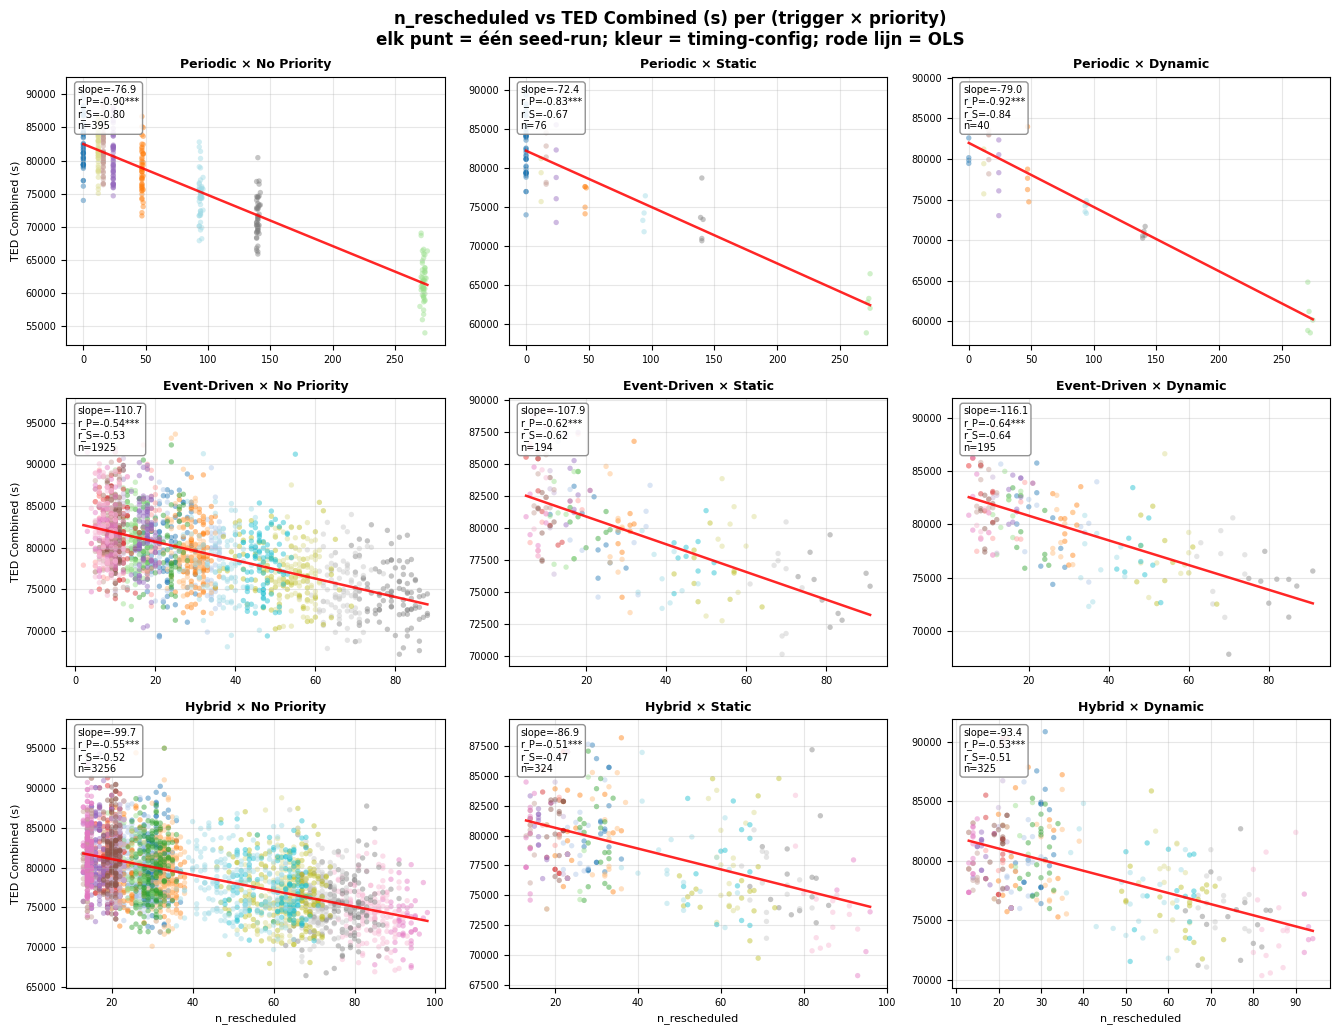

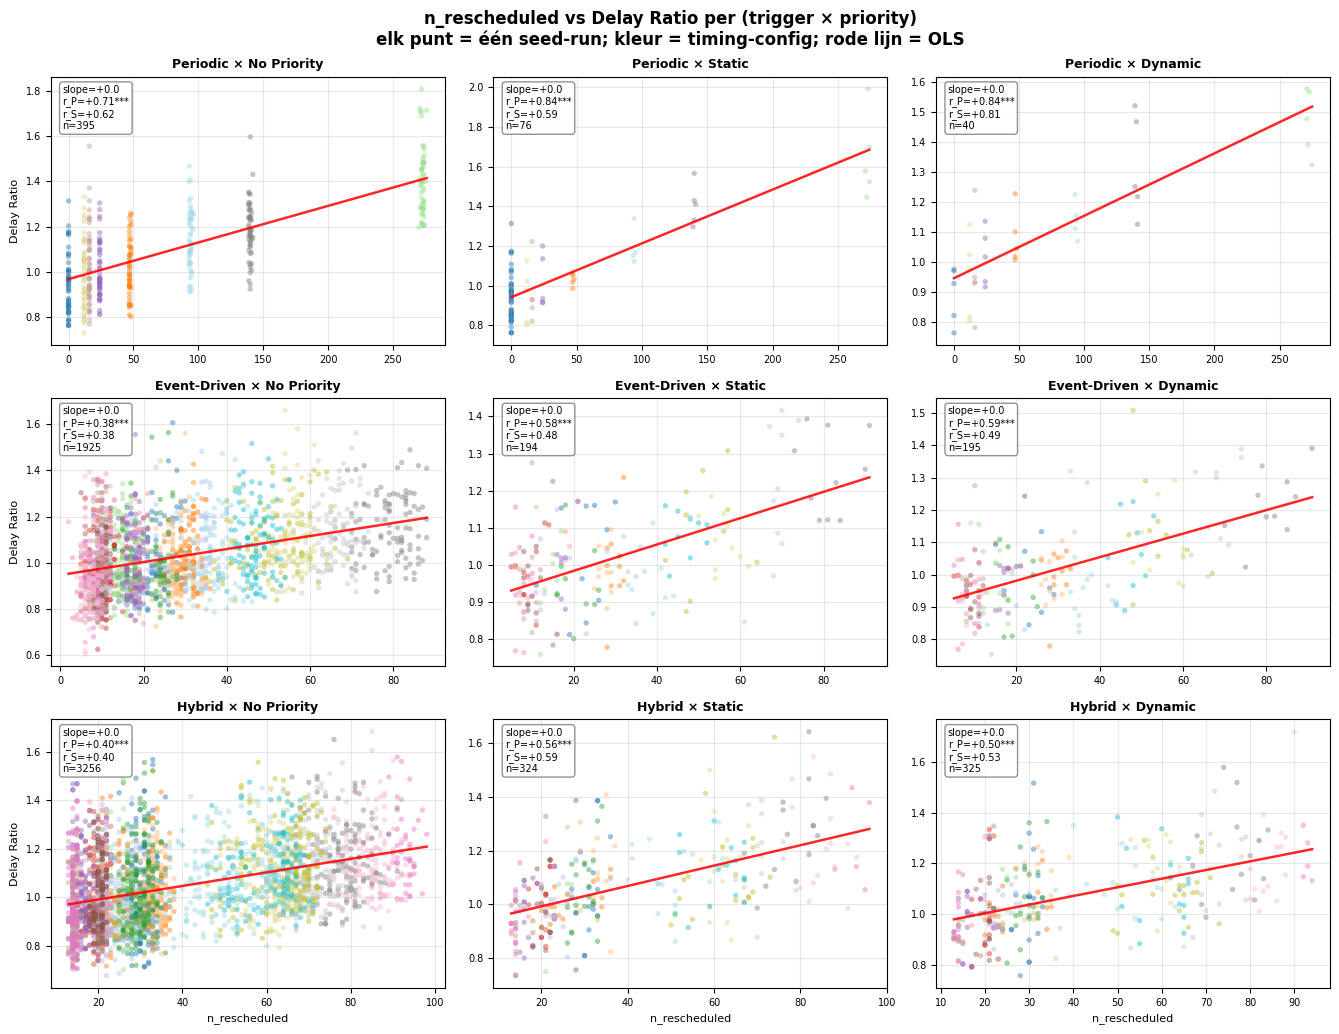

In [30]:
### 6.X — n_rescheduled vs metrics, per (trigger × priority)
from scipy.stats import pearsonr, spearmanr

def plot_n_resched_vs_metric(metric: str, ylabel: str = None):
    """3×3 grid: n_rescheduled (x) vs metric (y) per (trigger × priority) cel,
    met OLS-regressielijn en correlatie-statistieken."""
    if ylabel is None:
        ylabel = metric

    n_rows, n_cols = len(TRIGGER_ORDER), len(PRIORITY_ORDER)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4.5 * n_cols, 3.5 * n_rows),
                             squeeze=False)
    fig.suptitle(f"n_rescheduled vs {ylabel} per (trigger × priority)\n"
                 "elk punt = één seed-run; kleur = timing-config; rode lijn = OLS",
                 fontsize=12, fontweight="bold")

    for i, trigger in enumerate(TRIGGER_ORDER):
        for j, priority in enumerate(PRIORITY_ORDER):
            ax = axes[i, j]
            sub = raw[(raw["trigger"] == trigger) & (raw["priority"] == priority)]
            sub = sub.dropna(subset=["n_rescheduled", metric])

            if len(sub) < 5 or sub["n_rescheduled"].std() == 0:
                ax.set_title(f"{TRIGGER_LABELS[trigger]} × {PRIORITY_LABELS[priority]}",
                             fontsize=9)
                ax.text(0.5, 0.5, "(geen variatie / weinig data)",
                        ha="center", va="center", transform=ax.transAxes,
                        fontsize=9, color="gray")
                ax.set_xticks([]); ax.set_yticks([])
                continue

            # Scatter — één kleur per timing-config binnen deze cel
            configs_in_cell = sub["config"].unique()
            cmap = plt.cm.tab20(np.linspace(0, 1, max(len(configs_in_cell), 2)))
            for cfg, col in zip(configs_in_cell, cmap):
                d = sub[sub["config"] == cfg]
                ax.scatter(d["n_rescheduled"], d[metric],
                           c=[col], alpha=0.45, s=15, edgecolors="none")

            # OLS-regressie
            x = sub["n_rescheduled"].values.astype(float)
            y = sub[metric].values.astype(float)
            slope, intercept = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 50)
            ax.plot(x_line, slope * x_line + intercept,
                    "r-", linewidth=1.8, alpha=0.85)

            # Statistieken in hoek
            r_p, p_p = pearsonr(x, y)
            r_s, _   = spearmanr(x, y)
            sig = "***" if p_p < .001 else ("**" if p_p < .01 else ("*" if p_p < .05 else ""))
            ax.text(0.03, 0.97,
                    f"slope={slope:+.1f}\nr_P={r_p:+.2f}{sig}\nr_S={r_s:+.2f}\nn={len(sub)}",
                    transform=ax.transAxes, fontsize=7, va="top", ha="left",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                              edgecolor="gray", alpha=0.85))

            ax.set_title(f"{TRIGGER_LABELS[trigger]} × {PRIORITY_LABELS[priority]}",
                         fontsize=9, fontweight="bold")
            ax.set_xlabel("n_rescheduled" if i == n_rows - 1 else "", fontsize=8)
            ax.set_ylabel(ylabel if j == 0 else "", fontsize=8)
            ax.tick_params(labelsize=7)
            ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIG_DIR / f"n_resched_vs_{metric}.png", dpi=150, bbox_inches="tight")
    plt.show()


# Beide hoofdmetrics
plot_n_resched_vs_metric("TED_combined", "TED Combined (s)")
plot_n_resched_vs_metric("delay_ratio",  "Delay Ratio")

In [31]:
### 6.X+1 — Spearman correlatie n_rescheduled vs metrics, per cel
METRICS_VS_N = ["TED_combined", "TED_passenger", "TED_freight",
                "delay_ratio", "total_solve_time"]

corr_rows = []
for trigger in TRIGGER_ORDER:
    for priority in PRIORITY_ORDER:
        sub = raw[(raw["trigger"] == trigger) & (raw["priority"] == priority)]
        sub = sub.dropna(subset=["n_rescheduled"])
        if len(sub) < 3:
            continue

        r = {"trigger": trigger, "priority": priority, "n": len(sub)}
        for metric in METRICS_VS_N:
            if metric not in sub.columns:
                continue
            valid = sub.dropna(subset=[metric])
            if len(valid) < 3 or valid["n_rescheduled"].std() == 0:
                r[metric] = "—"
                continue
            rho, p = spearmanr(valid["n_rescheduled"], valid[metric])
            sig = "***" if p < .001 else ("**" if p < .01 else ("*" if p < .05 else ""))
            r[metric] = f"{rho:+.2f}{sig}"
        corr_rows.append(r)

corr_df = pd.DataFrame(corr_rows).set_index(["trigger", "priority"])
print("Spearman correlatie tussen n_rescheduled en metrics, per (trigger × priority)")
print("(* p<.05, ** p<.01, *** p<.001)")
display(corr_df)

corr_df.to_csv(RESULTS_DIR / "n_rescheduled_correlations.csv")
print(f"\nOpgeslagen: {RESULTS_DIR / 'n_rescheduled_correlations.csv'}")

Spearman correlatie tussen n_rescheduled en metrics, per (trigger × priority)
(* p<.05, ** p<.01, *** p<.001)


n TED_combined TED_passenger TED_freight  \
trigger      priority                                                   
periodic     no_priority   395     -0.80***      -0.85***       +0.10   
             static         76     -0.67***      -0.72***     +0.35**   
             dynamic        40     -0.84***      -0.90***      +0.35*   
event_driven no_priority  1925     -0.53***      -0.66***    +0.13***   
             static        194     -0.62***      -0.72***     +0.19**   
             dynamic       195     -0.64***      -0.74***      +0.17*   
hybrid       no_priority  3256     -0.52***      -0.67***    +0.17***   
             static        324     -0.47***      -0.67***    +0.36***   
             dynamic       325     -0.51***      -0.69***    +0.33***   

                         delay_ratio total_solve_time  
trigger      priority                                  
periodic     no_priority    +0.62***         +0.99***  
             static         +0.59***         +1.00***  
             dynamic        +0.81***         +0.99***  
event_driven no_priority    +0.38***         +0.99***  
             static         +0.48***         +0.98***  
             dynamic        +0.49***         +0.98***  
hybrid       no_priority    +0.40***         +0.98***  
             static         +0.59***         +0.97***  
             dynamic        +0.53***         +0.98***


Opgeslagen: /Users/ddw/Desktop/Rescheduling/results/fase1_full_extreme_weights_5/n_rescheduled_correlations.csv


3x3 Full factorial

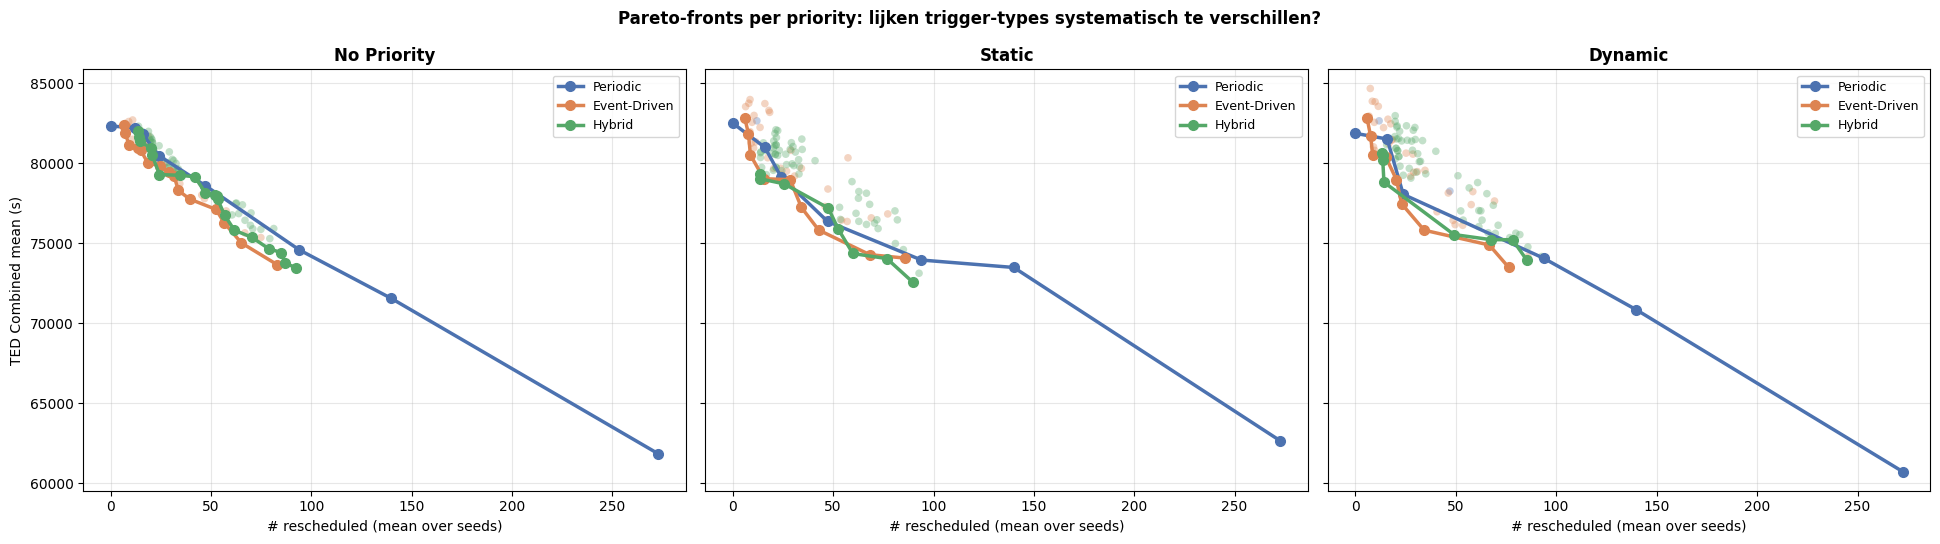

In [32]:
### Eerste indruk: Pareto per priority, kleuren per trigger
def pareto_front_2d(df, x_col, y_col):
    sub = df.sort_values(x_col).reset_index(drop=True)
    front, best_y = [], float("inf")
    for _, r in sub.iterrows():
        if r[y_col] < best_y:
            front.append(r); best_y = r[y_col]
    return pd.DataFrame(front)

# Aggregate per (config × priority)
key_cols = ["strategy_type", "priority", "periodic_rf", "event_driven_rf",
            "controller_freq", "threshold_conf"]
per_combo = (raw.groupby(key_cols, dropna=False, observed=True)
                .agg(TED_mean   = ("TED_combined",  "mean"),
                     n_resched  = ("n_rescheduled", "mean"),
                     DR_mean    = ("delay_ratio",   "mean"))
                .reset_index())

fig, axes = plt.subplots(1, len(PRIORITY_ORDER),
                          figsize=(6.5*len(PRIORITY_ORDER), 5.5), sharey=True)
if len(PRIORITY_ORDER) == 1: axes = [axes]
fig.suptitle("Pareto-fronts per priority: lijken trigger-types systematisch te verschillen?",
             fontsize=12, fontweight="bold")

for ax, priority in zip(axes, PRIORITY_ORDER):
    sub = per_combo[per_combo["priority"] == priority]
    for trigger in TRIGGER_ORDER:
        d = sub[sub["strategy_type"] == trigger]
        if d.empty: continue
        ax.scatter(d["n_resched"], d["TED_mean"],
                   c=TRIGGER_COLORS[trigger], alpha=0.35, s=30, edgecolors="none")
        pf = pareto_front_2d(d, "n_resched", "TED_mean")
        if len(pf) >= 2:
            ax.plot(pf["n_resched"], pf["TED_mean"],
                    color=TRIGGER_COLORS[trigger], linewidth=2.5,
                    marker="o", markersize=7, label=TRIGGER_LABELS[trigger])
    ax.set_xlabel("# rescheduled (mean over seeds)")
    if priority == PRIORITY_ORDER[0]: ax.set_ylabel("TED Combined mean (s)")
    ax.set_title(PRIORITY_LABELS[priority], fontweight="bold")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "pareto_per_priority_x_trigger.png", dpi=150, bbox_inches="tight")
plt.show()

In [33]:
### Hierarchical regression: trigger, priority, interactie, na controle voor effort
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

sub = per_combo.dropna(subset=["TED_mean", "n_resched"]).copy()
sub["strategy_type"] = pd.Categorical(sub["strategy_type"], categories=TRIGGER_ORDER)
sub["priority"]      = pd.Categorical(sub["priority"],      categories=PRIORITY_ORDER)

# Vijf nested modellen
m0 = smf.ols("TED_mean ~ 1",                                                            data=sub).fit()
m1 = smf.ols("TED_mean ~ n_resched",                                                    data=sub).fit()
m2 = smf.ols("TED_mean ~ n_resched + C(strategy_type)",                                 data=sub).fit()
m3 = smf.ols("TED_mean ~ n_resched + C(strategy_type) + C(priority)",                   data=sub).fit()
m4 = smf.ols("TED_mean ~ n_resched + C(strategy_type) * C(priority)",                   data=sub).fit()

print(f"n configs in dataset: {len(sub)}\n")
print("Hierarchische modelvergelijking — voegt elke term significant uitleg toe?\n")
print(f"  M0  intercept only                       R² = {m0.rsquared:.4f}")
print(f"  M1  + n_rescheduled                      R² = {m1.rsquared:.4f}")
print(f"  M2  + trigger                            R² = {m2.rsquared:.4f}")
print(f"  M3  + priority                           R² = {m3.rsquared:.4f}")
print(f"  M4  + trigger × priority interactie      R² = {m4.rsquared:.4f}\n")

def lr_test(small, large, label):
    aov = anova_lm(small, large)
    F, p = aov["F"].iloc[1], aov["Pr(>F)"].iloc[1]
    sig = "***" if p < .001 else ("**" if p < .01 else ("*" if p < .05 else "ns"))
    print(f"  {label:<45}  F={F:6.2f}  p={p:.4f}  {sig}")

print("F-tests voor elke toevoeging:")
lr_test(m0, m1, "M1 vs M0  → effort (n_rescheduled)")
lr_test(m1, m2, "M2 vs M1  → trigger | effort")
lr_test(m2, m3, "M3 vs M2  → priority | effort + trigger")
lr_test(m3, m4, "M4 vs M3  → trigger × priority interactie")

# Coefficients van het volledige model
print("\nCoefficients van het volledige model (M4):")
print(m4.summary().tables[1])

n configs in dataset: 339

Hierarchische modelvergelijking — voegt elke term significant uitleg toe?

  M0  intercept only                       R² = 0.0000
  M1  + n_rescheduled                      R² = 0.8650
  M2  + trigger                            R² = 0.8675
  M3  + priority                           R² = 0.8676
  M4  + trigger × priority interactie      R² = 0.8690

F-tests voor elke toevoeging:
  M1 vs M0  → effort (n_rescheduled)             F=2158.82  p=0.0000  ***
  M2 vs M1  → trigger | effort                   F=  3.15  p=0.0443  *
  M3 vs M2  → priority | effort + trigger        F=  0.15  p=0.8645  ns
  M4 vs M3  → trigger × priority interactie      F=  0.92  p=0.4549  ns

Coefficients van het volledige model (M4):
                                                              coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------
Intercept  

Predicties berekend bij n_rescheduled = 28 (mediaan)


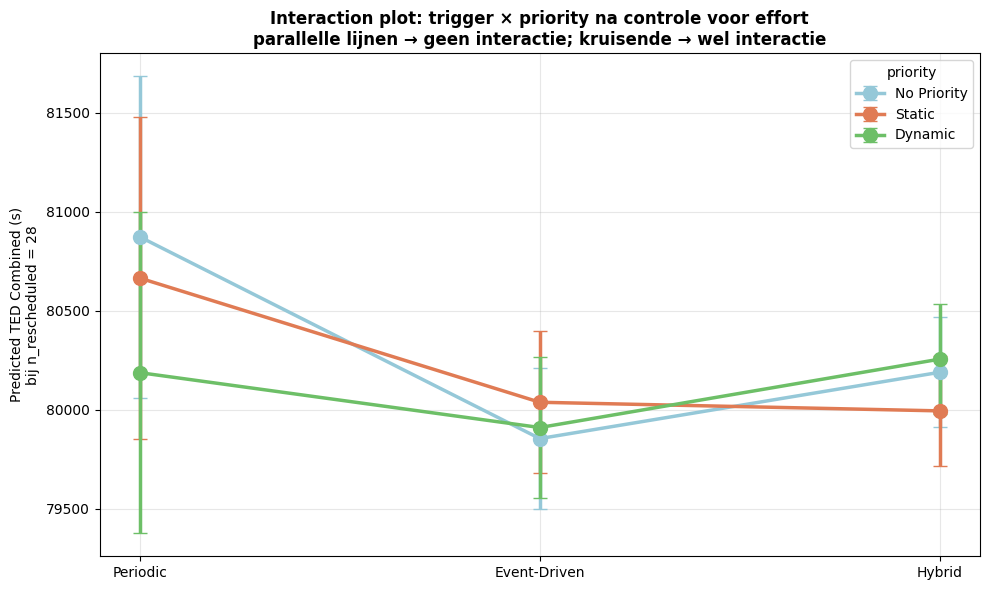

In [34]:
### Interaction plot: predicted TED per (trigger × priority) bij vaste effort
import numpy as np

# Kies effort-anker: mediaan van je dataset (representatief)
effort_anchor = sub["n_resched"].median()
print(f"Predicties berekend bij n_rescheduled = {effort_anchor:.0f} (mediaan)")

# Bouw predictie-grid
grid = pd.DataFrame([
    {"strategy_type": t, "priority": p, "n_resched": effort_anchor}
    for t in TRIGGER_ORDER for p in PRIORITY_ORDER
])
grid["strategy_type"] = pd.Categorical(grid["strategy_type"], categories=TRIGGER_ORDER)
grid["priority"]      = pd.Categorical(grid["priority"],      categories=PRIORITY_ORDER)

# Predict met 95% CI uit model M4
pred = m4.get_prediction(grid).summary_frame(alpha=0.05)
grid["TED_pred"] = pred["mean"]
grid["TED_lo"]   = pred["mean_ci_lower"]
grid["TED_hi"]   = pred["mean_ci_upper"]

# Plot: x-as = trigger, lijnen per priority
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(TRIGGER_ORDER))
for priority in PRIORITY_ORDER:
    d = grid[grid["priority"] == priority].sort_values(
        by="strategy_type", key=lambda s: pd.Categorical(s, categories=TRIGGER_ORDER).codes)
    yerr = [d["TED_pred"] - d["TED_lo"], d["TED_hi"] - d["TED_pred"]]
    ax.errorbar(x_pos, d["TED_pred"], yerr=yerr,
                marker="o", markersize=10, linewidth=2.5, capsize=5,
                label=PRIORITY_LABELS[priority], color=PRIORITY_COLORS[priority])

ax.set_xticks(x_pos)
ax.set_xticklabels([TRIGGER_LABELS[t] for t in TRIGGER_ORDER])
ax.set_ylabel(f"Predicted TED Combined (s)\nbij n_rescheduled = {effort_anchor:.0f}")
ax.set_title("Interaction plot: trigger × priority na controle voor effort\n"
             "parallelle lijnen → geen interactie; kruisende → wel interactie",
             fontweight="bold")
ax.legend(title="priority", fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "interaction_emmeans.png", dpi=150, bbox_inches="tight")
plt.show()

In [35]:
### Post-hoc: alleen draaien als M4 vs M3 significant was
from itertools import combinations
from scipy.stats import mannwhitneyu

# Werk op individuele runs ipv mean per config voor power
print("Pairwise Mann-Whitney binnen elke priority (paarsgewijs over triggers)")
print("(Bonferroni: 3 paren × 3 priorities = 9 vergelijkingen → α_adj = 0.05/9 = 0.0056)\n")
n_total = 3 * 3
for priority in PRIORITY_ORDER:
    print(f"=== priority: {priority} ===")
    for t1, t2 in combinations(TRIGGER_ORDER, 2):
        d1 = raw[(raw["priority"] == priority) & (raw["strategy_type"] == t1)]["TED_combined"].dropna()
        d2 = raw[(raw["priority"] == priority) & (raw["strategy_type"] == t2)]["TED_combined"].dropna()
        if len(d1) < 2 or len(d2) < 2: continue
        _, p = mannwhitneyu(d1, d2, alternative="two-sided")
        p_adj = min(p * n_total, 1.0)
        sig = "***" if p_adj < .001 else ("**" if p_adj < .01 else ("*" if p_adj < .05 else "ns"))
        print(f"  {t1:<13} vs {t2:<13}  Δmean={d1.mean()-d2.mean():+8.0f}s  p_adj={p_adj:.4f}  {sig}")
    print()

Pairwise Mann-Whitney binnen elke priority (paarsgewijs over triggers)
(Bonferroni: 3 paren × 3 priorities = 9 vergelijkingen → α_adj = 0.05/9 = 0.0056)

=== priority: no_priority ===
  periodic      vs event_driven   Δmean=   -3123s  p_adj=0.0000  ***
  periodic      vs hybrid         Δmean=   -2552s  p_adj=0.0000  ***
  event_driven  vs hybrid         Δmean=    +571s  p_adj=0.0000  ***

=== priority: static ===
  periodic      vs event_driven   Δmean=    -492s  p_adj=1.0000  ns
  periodic      vs hybrid         Δmean=    +489s  p_adj=0.4901  ns
  event_driven  vs hybrid         Δmean=    +981s  p_adj=0.0531  ns

=== priority: dynamic ===
  periodic      vs event_driven   Δmean=   -3783s  p_adj=0.0210  *
  periodic      vs hybrid         Δmean=   -3246s  p_adj=0.1411  ns
  event_driven  vs hybrid         Δmean=    +537s  p_adj=0.4721  ns



In [36]:
# Priority hoort hier zijn effect te tonen: verschuiving freight/passenger ratio
m1_dr = smf.ols("DR_mean ~ n_resched",                                            data=sub).fit()
m2_dr = smf.ols("DR_mean ~ n_resched + C(strategy_type)",                         data=sub).fit()
m3_dr = smf.ols("DR_mean ~ n_resched + C(strategy_type) + C(priority)",           data=sub).fit()
m4_dr = smf.ols("DR_mean ~ n_resched + C(strategy_type) * C(priority)",           data=sub).fit()

print("Hierarchische regression voor delay_ratio (DR):\n")
print(f"  M1 (effort):                       R² = {m1_dr.rsquared:.4f}")
print(f"  M2 (+ trigger):                    R² = {m2_dr.rsquared:.4f}")
print(f"  M3 (+ priority):                   R² = {m3_dr.rsquared:.4f}")
print(f"  M4 (+ trigger × priority):         R² = {m4_dr.rsquared:.4f}\n")
lr_test(m1_dr, m2_dr, "trigger | effort")
lr_test(m2_dr, m3_dr, "priority | effort + trigger")
lr_test(m3_dr, m4_dr, "trigger × priority interactie")
print()
print(m4_dr.summary().tables[1])

Hierarchische regression voor delay_ratio (DR):

  M1 (effort):                       R² = 0.7740
  M2 (+ trigger):                    R² = 0.7874
  M3 (+ priority):                   R² = 0.7903
  M4 (+ trigger × priority):         R² = 0.7995

  trigger | effort                               F= 10.56  p=0.0000  ***
  priority | effort + trigger                    F=  2.26  p=0.1065  ns
  trigger × priority interactie                  F=  3.78  p=0.0050  **

                                                              coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------
Intercept                                                   0.8872      0.017     51.752      0.000       0.853       0.921
C(strategy_type)[T.event_driven]                            0.0638      0.018      3.534      0.000       0.028       0.099
C(strategy_type)[T.hybrid]              

In [37]:
### Helper: hierarchische regression voor een willekeurige outcome
def hierarchical_anova(outcome: str, sub: pd.DataFrame, effort_var: str = "n_resched") -> dict:
    """Run M0-M4 hierarchical ANCOVA op outcome, return summary."""
    df = sub.dropna(subset=[outcome, effort_var]).copy()
    df["strategy_type"] = pd.Categorical(df["strategy_type"], categories=TRIGGER_ORDER)
    df["priority"]      = pd.Categorical(df["priority"],      categories=PRIORITY_ORDER)

    m0 = smf.ols(f"{outcome} ~ 1",                                                       data=df).fit()
    m1 = smf.ols(f"{outcome} ~ {effort_var}",                                            data=df).fit()
    m2 = smf.ols(f"{outcome} ~ {effort_var} + C(strategy_type)",                         data=df).fit()
    m3 = smf.ols(f"{outcome} ~ {effort_var} + C(strategy_type) + C(priority)",           data=df).fit()
    m4 = smf.ols(f"{outcome} ~ {effort_var} + C(strategy_type) * C(priority)",           data=df).fit()

    print(f"\n{'='*70}")
    print(f"Outcome: {outcome}  (n = {len(df)})")
    print(f"{'='*70}")
    print(f"  M1 (effort):                    R² = {m1.rsquared:.4f}")
    print(f"  M2 (+ trigger):                 R² = {m2.rsquared:.4f}")
    print(f"  M3 (+ priority):                R² = {m3.rsquared:.4f}")
    print(f"  M4 (+ interactie):              R² = {m4.rsquared:.4f}\n")
    lr_test(m1, m2, "trigger | effort")
    lr_test(m2, m3, "priority | effort + trigger")
    lr_test(m3, m4, "trigger × priority interactie")
    print("\nCoefficients (M4):")
    print(m4.summary().tables[1])
    return {"m0": m0, "m1": m1, "m2": m2, "m3": m3, "m4": m4}

# Draai voor passenger en freight apart
res_pax = hierarchical_anova("TED_passenger_mean", per_combo_renamed)
res_frt = hierarchical_anova("TED_freight_mean",   per_combo_renamed)

NameError: name 'per_combo_renamed' is not defined

In [ ]:
### Cel A — per_combo opnieuw berekenen met alle outcome-kolommen
key_cols = ["strategy_type", "priority", "periodic_rf", "event_driven_rf",
            "controller_freq", "threshold_conf"]

# Pas kolom-namen aan als TAD anders heet in jouw raw data
available_metrics = {
    "TED_combined":   "TED_mean",
    "TED_passenger":  "TED_passenger_mean",
    "TED_freight":    "TED_freight_mean",
    "delay_ratio":    "DR_mean",
    "n_rescheduled":  "n_resched",
    "total_solve_time": "solve_time_mean",
}
# Voeg TAD toe als de kolommen bestaan in raw:
for col in ["TAD_passenger", "TAD_freight", "TAD_combined"]:
    if col in raw.columns:
        available_metrics[col] = f"{col}_mean"

agg_dict = {
    new_name: (orig, "mean")
    for orig, new_name in available_metrics.items()
    if orig in raw.columns
}

per_combo = (raw.groupby(key_cols, dropna=False, observed=True)
                .agg(**agg_dict)
                .reset_index())

print(f"per_combo: {len(per_combo)} rijen")
print(f"Kolommen: {[c for c in per_combo.columns if '_mean' in c or c=='n_resched']}")

per_combo: 339 rijen
Kolommen: ['TED_mean', 'TED_passenger_mean', 'TED_freight_mean', 'DR_mean', 'n_resched', 'solve_time_mean', 'TAD_passenger_mean', 'TAD_freight_mean', 'TAD_combined_mean']


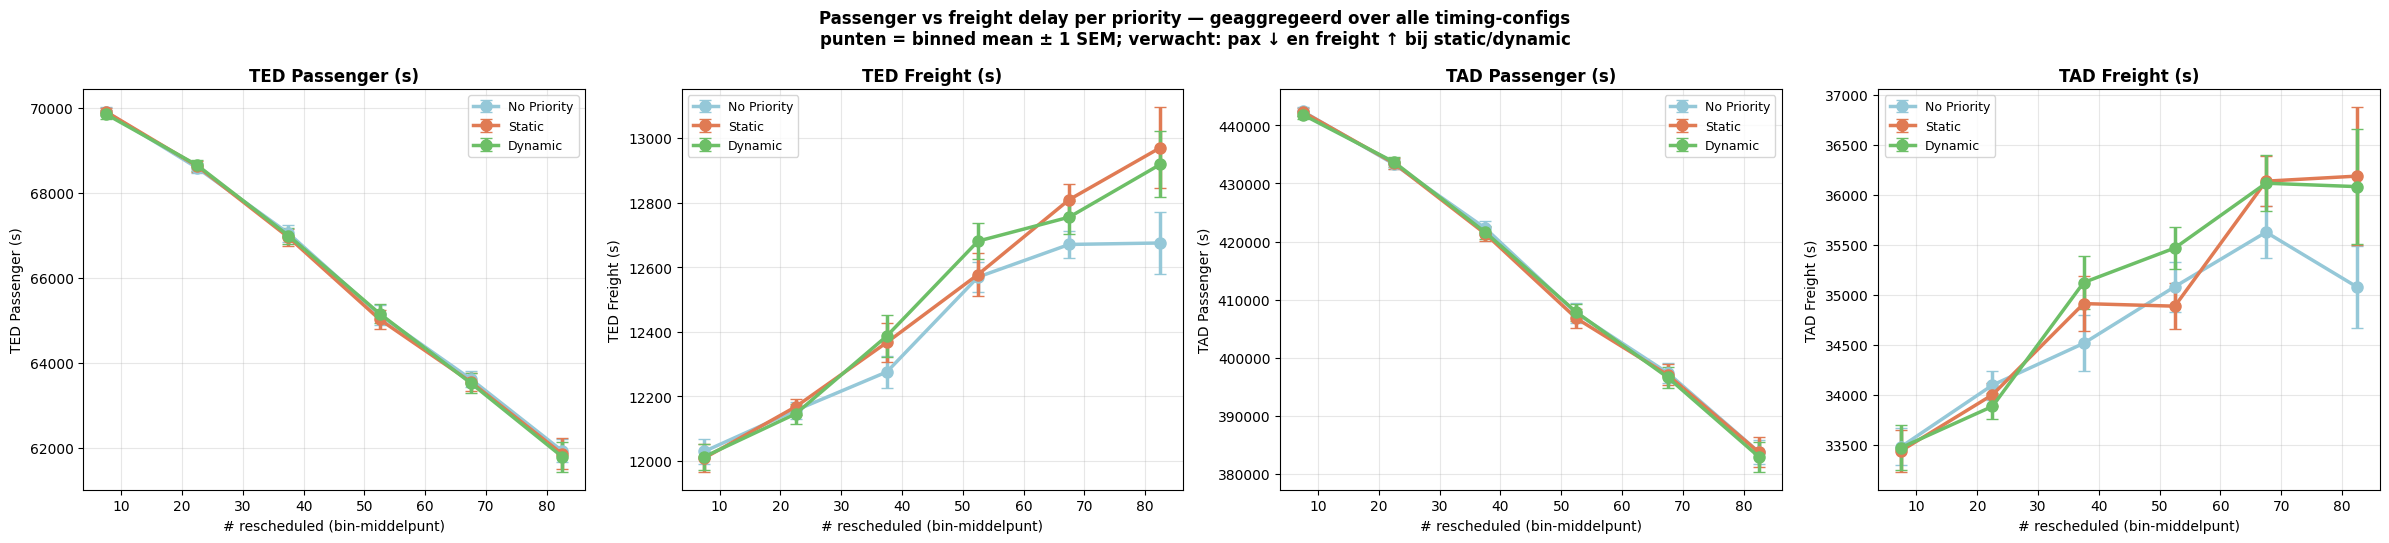

In [ ]:
### Cel B — Visualisatie: pax/freight delay vs effort, per priority (geaggregeerd)
from scipy.stats import sem

RESCHED_BINS = [0, 15, 30, 45, 60, 75, 90, 105]
BIN_LABELS   = [f"{a}–{b}" for a, b in zip(RESCHED_BINS[:-1], RESCHED_BINS[1:])]
bin_centers  = [(a + b) / 2 for a, b in zip(RESCHED_BINS[:-1], RESCHED_BINS[1:])]

per_combo["resched_bin"] = pd.cut(per_combo["n_resched"],
                                   bins=RESCHED_BINS, labels=BIN_LABELS, right=False)

outcomes = [
    ("TED_passenger_mean", "TED Passenger (s)"),
    ("TED_freight_mean",   "TED Freight (s)"),
]
# Voeg TAD toe als beschikbaar
for col, label in [("TAD_passenger_mean", "TAD Passenger (s)"),
                   ("TAD_freight_mean",   "TAD Freight (s)")]:
    if col in per_combo.columns:
        outcomes.append((col, label))

n_plots = len(outcomes)
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5.5), sharey=False)
if n_plots == 1: axes = [axes]

fig.suptitle("Passenger vs freight delay per priority — geaggregeerd over alle timing-configs\n"
             "punten = binned mean ± 1 SEM; verwacht: pax ↓ en freight ↑ bij static/dynamic",
             fontsize=12, fontweight="bold")

for ax, (metric, ylabel) in zip(axes, outcomes):
    if metric not in per_combo.columns:
        ax.set_visible(False); continue
    for priority in PRIORITY_ORDER:
        sub = per_combo[per_combo["priority"] == priority]
        x_vals, y_vals, y_errs = [], [], []
        for bin_label, center in zip(BIN_LABELS, bin_centers):
            d = sub[sub["resched_bin"] == bin_label][metric].dropna()
            if len(d) >= 3:
                x_vals.append(center)
                y_vals.append(d.mean())
                y_errs.append(sem(d))

        if x_vals:
            ax.errorbar(x_vals, y_vals, yerr=y_errs,
                        marker="o", markersize=8, linewidth=2.5, capsize=4,
                        color=PRIORITY_COLORS[priority],
                        label=PRIORITY_LABELS[priority])

    ax.set_xlabel("# rescheduled (bin-middelpunt)")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel, fontweight="bold")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "pax_freight_vs_effort_per_priority.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print(base_key)

['strategy_type', 'periodic_rf', 'event_driven_rf', 'controller_freq', 'threshold_conf']


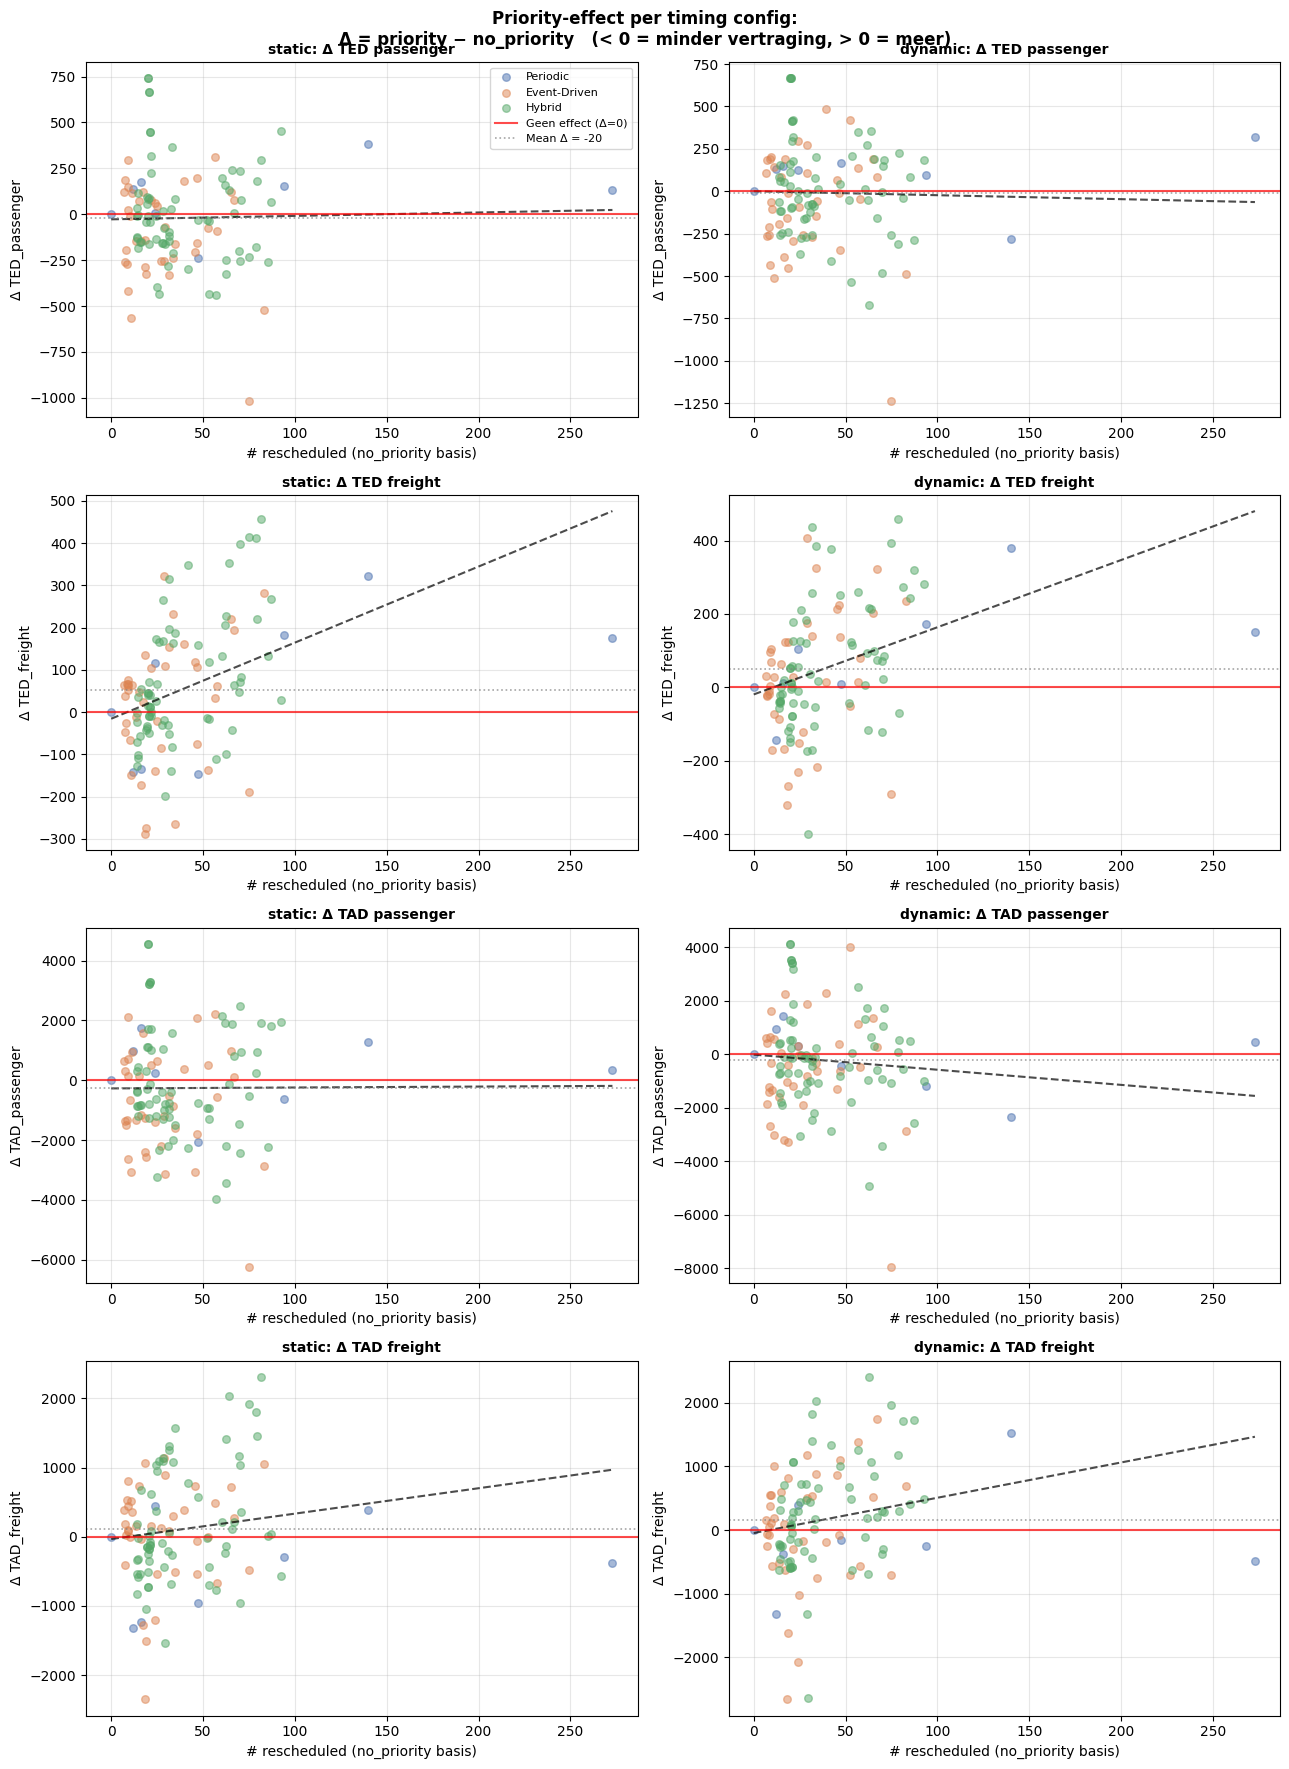

In [ ]:
### Cel C — Delta-plot: Δ priority-effect per timing config

# strategy_type hoort NIET in de sleutel:
base_key = ["periodic_rf", "event_driven_rf",
            "controller_freq", "threshold_conf"]

delta_metrics = [c for c in [
    "TED_passenger_mean",
    "TED_freight_mean",
    "TAD_passenger_mean",
    "TAD_freight_mean"
] if c in per_combo.columns]

if "no_priority" not in per_combo["priority"].values:
    print("Geen no_priority aanwezig — delta-plot niet mogelijk")

else:
    n_dm = len(delta_metrics)
    n_pr = len([p for p in PRIORITY_ORDER if p != "no_priority"])

    fig, axes = plt.subplots(
        n_dm,
        n_pr,
        figsize=(6.5 * n_pr, 4.5 * n_dm),
        sharey=False,
        squeeze=False
    )

    fig.suptitle(
        "Priority-effect per timing config:\n"
        "Δ = priority − no_priority   "
        "(< 0 = minder vertraging, > 0 = meer)",
        fontsize=12,
        fontweight="bold"
    )

    for i, metric in enumerate(delta_metrics):

        # Eén kolom per priority
        pivot = per_combo.pivot_table(
            index=base_key,
            columns="priority",
            values=metric,
            dropna=False
        )

        effort = per_combo.pivot_table(
            index=base_key,
            columns="priority",
            values="n_resched",
            dropna=False
        )

        effort_ref = effort.get(
            "no_priority",
            effort.mean(axis=1)
        )

        # Mapping timing config -> strategy_type
        strategy_map = (
            per_combo
            .drop_duplicates(base_key)
            .set_index(base_key)["strategy_type"]
        )

        j = 0

        for priority in [p for p in PRIORITY_ORDER if p != "no_priority"]:

            ax = axes[i, j]

            if (
                "no_priority" not in pivot.columns
                or priority not in pivot.columns
            ):
                ax.set_visible(False)
                j += 1
                continue

            delta = pivot[priority] - pivot["no_priority"]

            df_delta = pd.DataFrame({
                "effort": effort_ref,
                "delta": delta
            }).dropna()

            # strategy toevoegen via mapping
            df_delta["strategy"] = (
                df_delta.index.map(strategy_map)
            )

            for trigger in TRIGGER_ORDER:

                d = df_delta[
                    df_delta["strategy"] == trigger
                ]

                ax.scatter(
                    d["effort"],
                    d["delta"],
                    color=TRIGGER_COLORS[trigger],
                    alpha=0.5,
                    s=30,
                    label=TRIGGER_LABELS[trigger]
                )

            # Regressielijn
            if len(df_delta) > 5:

                slope, intercept = np.polyfit(
                    df_delta["effort"],
                    df_delta["delta"],
                    1
                )

                x_l = np.linspace(
                    df_delta["effort"].min(),
                    df_delta["effort"].max(),
                    50
                )

                ax.plot(
                    x_l,
                    slope * x_l + intercept,
                    "k--",
                    linewidth=1.5,
                    alpha=0.7
                )

            # Referentielijnen
            ax.axhline(
                0,
                color="red",
                linestyle="-",
                linewidth=1.5,
                alpha=0.7,
                label="Geen effect (Δ=0)"
            )

            mean_d = df_delta["delta"].mean()

            ax.axhline(
                mean_d,
                color="gray",
                linestyle=":",
                linewidth=1.2,
                alpha=0.7,
                label=f"Mean Δ = {mean_d:.0f}"
            )

            ax.set_xlabel("# rescheduled (no_priority basis)")

            ax.set_ylabel(
                f"Δ {metric.replace('_mean','')}"
            )

            ax.set_title(
                f"{priority}: Δ "
                f"{metric.replace('_mean','').replace('_',' ')}",
                fontsize=10,
                fontweight="bold"
            )

            if i == 0 and j == 0:
                ax.legend(
                    fontsize=8,
                    loc="upper right"
                )

            ax.grid(alpha=0.3)

            j += 1

    plt.tight_layout()

    plt.savefig(
        FIG_DIR / "delta_priority_effect.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

In [ ]:
### Cel D — Multi-outcome hierarchische regressie
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

def hierarchical_anova(outcome: str, df: pd.DataFrame,
                        effort_var: str = "n_resched") -> pd.Series:
    """Run M1-M4 en return F-statistieken als Series."""
    data = df.dropna(subset=[outcome, effort_var]).copy()
    data["strategy_type"] = pd.Categorical(data["strategy_type"], categories=TRIGGER_ORDER)
    data["priority"]      = pd.Categorical(data["priority"],      categories=PRIORITY_ORDER)

    m1 = smf.ols(f"{outcome} ~ {effort_var}",                                       data=data).fit()
    m2 = smf.ols(f"{outcome} ~ {effort_var} + C(strategy_type)",                    data=data).fit()
    m3 = smf.ols(f"{outcome} ~ {effort_var} + C(strategy_type) + C(priority)",      data=data).fit()
    m4 = smf.ols(f"{outcome} ~ {effort_var} + C(strategy_type) * C(priority)",      data=data).fit()

    def ftest(small, large):
        aov = anova_lm(small, large)
        return aov["F"].iloc[1], aov["Pr(>F)"].iloc[1]

    F_trig, p_trig = ftest(m1, m2)
    F_prio, p_prio = ftest(m2, m3)
    F_int,  p_int  = ftest(m3, m4)

    def stars(p): return "***" if p<.001 else ("**" if p<.01 else ("*" if p<.05 else "ns"))

    return pd.Series({
        "n":            len(data),
        "R²_effort":    round(m1.rsquared, 4),
        "R²_trigger":   round(m2.rsquared, 4),
        "R²_priority":  round(m3.rsquared, 4),
        "R²_interact":  round(m4.rsquared, 4),
        "F_trigger":    round(F_trig, 2),  "p_trigger":  stars(p_trig),
        "F_priority":   round(F_prio, 2),  "p_priority": stars(p_prio),
        "F_interact":   round(F_int,  2),  "p_interact": stars(p_int),
        "slope_effort": round(m1.params[effort_var], 4),
    })


# Welke outcomes draaien?
all_outcomes = {
    "TED Combined":   "TED_mean",
    "TED Passenger":  "TED_passenger_mean",
    "TED Freight":    "TED_freight_mean",
    "Delay Ratio":    "DR_mean",
}
for col, label in [("TAD_passenger_mean", "TAD Passenger"),
                   ("TAD_freight_mean",   "TAD Freight"),
                   ("TAD_combined_mean",  "TAD Combined")]:
    if col in per_combo.columns:
        all_outcomes[label] = col

results = {}
for label, col in all_outcomes.items():
    if col in per_combo.columns:
        results[label] = hierarchical_anova(col, per_combo)
    else:
        print(f"Kolom {col} niet gevonden in per_combo — sla {label} over")

summary_df = pd.DataFrame(results).T
print("\nSamenvatting — hierarchische regressie voor alle outcomes:")
print("(Effect na controle voor effort)\n")
display(summary_df[["R²_effort", "R²_trigger", "R²_priority",
                     "F_trigger", "p_trigger", "F_priority", "p_priority",
                     "F_interact", "p_interact", "slope_effort"]])
summary_df.to_csv(RESULTS_DIR / "regression_all_outcomes.csv")
print(f"\nOpgeslagen: regression_all_outcomes.csv")


Samenvatting — hierarchische regressie voor alle outcomes:
(Effect na controle voor effort)



,R²_effort,R²_trigger,R²_priority,F_trigger,p_trigger,F_priority,p_priority,F_interact,p_interact,slope_effort
TED Combined,0.9442,0.9546,0.9546,38.04,***,0.13,ns,0.28,ns,-86.8833
TED Passenger,0.9398,0.9513,0.9513,39.69,***,0.02,ns,0.13,ns,-93.132
TED Freight,0.3767,0.4131,0.4181,10.37,***,1.45,ns,0.15,ns,6.2487
Delay Ratio,0.8904,0.9028,0.9036,21.33,***,1.44,ns,0.06,ns,0.0022
TAD Passenger,0.9509,0.9605,0.9605,40.74,***,0.1,ns,0.1,ns,-695.2719
TAD Freight,0.224,0.2641,0.2669,9.11,***,0.65,ns,0.4,ns,17.9205
TAD Combined,0.9527,0.9618,0.9618,39.83,***,0.03,ns,0.14,ns,-677.3514



Opgeslagen: regression_all_outcomes.csv
